## Data Cleaning 

In [2]:
#import neccesarry libraries
!pip install missingno

# Data Analysis
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt 

### Importing Data

In [4]:
# Import datset into data frame 

df = pd.read_csv(r"C:\Users\Ndumbi Kimani\Downloads\Customer-Churn.csv")

In [5]:
# Scout the data
# Datset top 5
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Datset bottom 5 

df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
## Check important data details

df.info()

# data seems to be clean without null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### Dropping irrelevant Feature

In [9]:
#Drop Customer ID as it has no significance on the analysis

df = df.drop(['customerID'], axis=1)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
# investigate numerical Variables

numerical_df = df.select_dtypes( exclude = "object")

numerical_df

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70
...,...,...,...
7038,0,24,84.80
7039,0,72,103.20
7040,0,11,29.60
7041,1,4,74.40


In [11]:
#Investigate categorical variables 

categorical_df = df.select_dtypes(include = "object", exclude = "float",)

categorical_df.head()

# total charges is numerical data and has been placed in categorical. 
# need to change the type.

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,1889.5,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,108.15,Yes
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),1840.75,No
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,151.65,Yes


In [12]:
# Total number of columns in the dataset

df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [14]:
# Convert Total Charges from string object to numeric variable

df['TotalCharges']= pd.to_numeric( df['TotalCharges'], errors='coerce' )

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


### Dealing with Missing Values

In [17]:
# confirm no null values
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [18]:
# Fill the missing objects observed after conversion to numeric

df["TotalCharges"] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

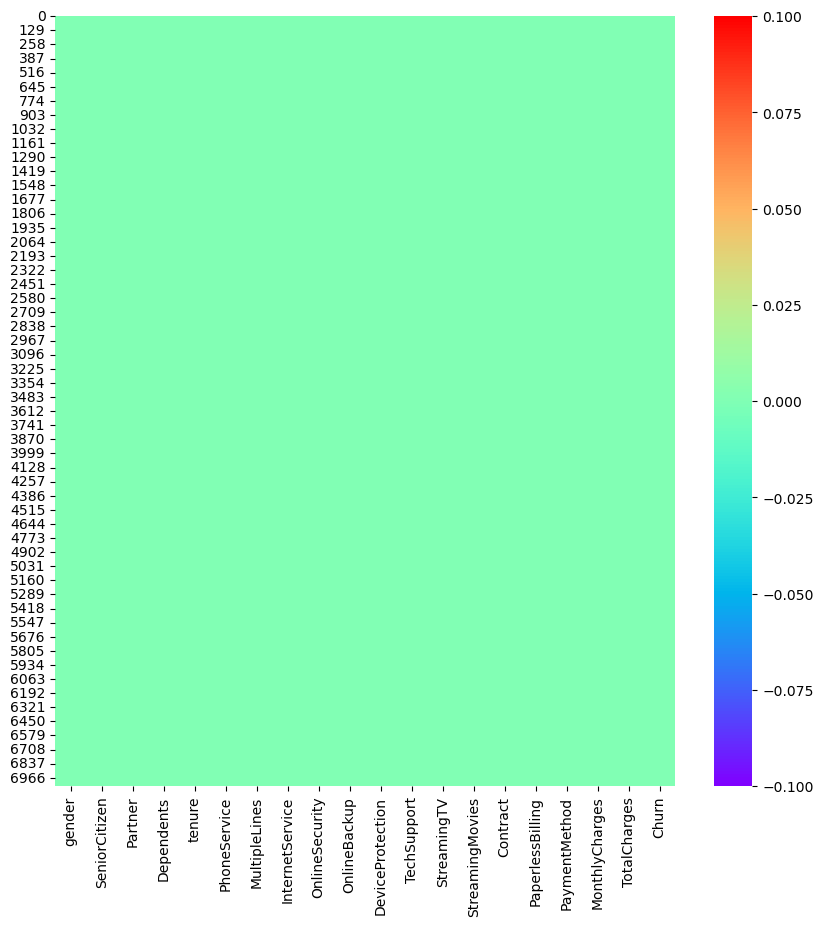

In [19]:
# HeatMap to visualise the missing data 

plt.figure ( figsize = (10,10))
sns.heatmap(df.isnull() , cbar=True ,cmap = "rainbow")

plt.show;

The heatmap shows that there are no missing values in the dataset. Each feature (such as gender, SeniorCitizen, tenure, etc.) has no gaps, represented by the uniform coloring across the entire grid.

In [21]:
#Clean the missing data 
import missingno as msno

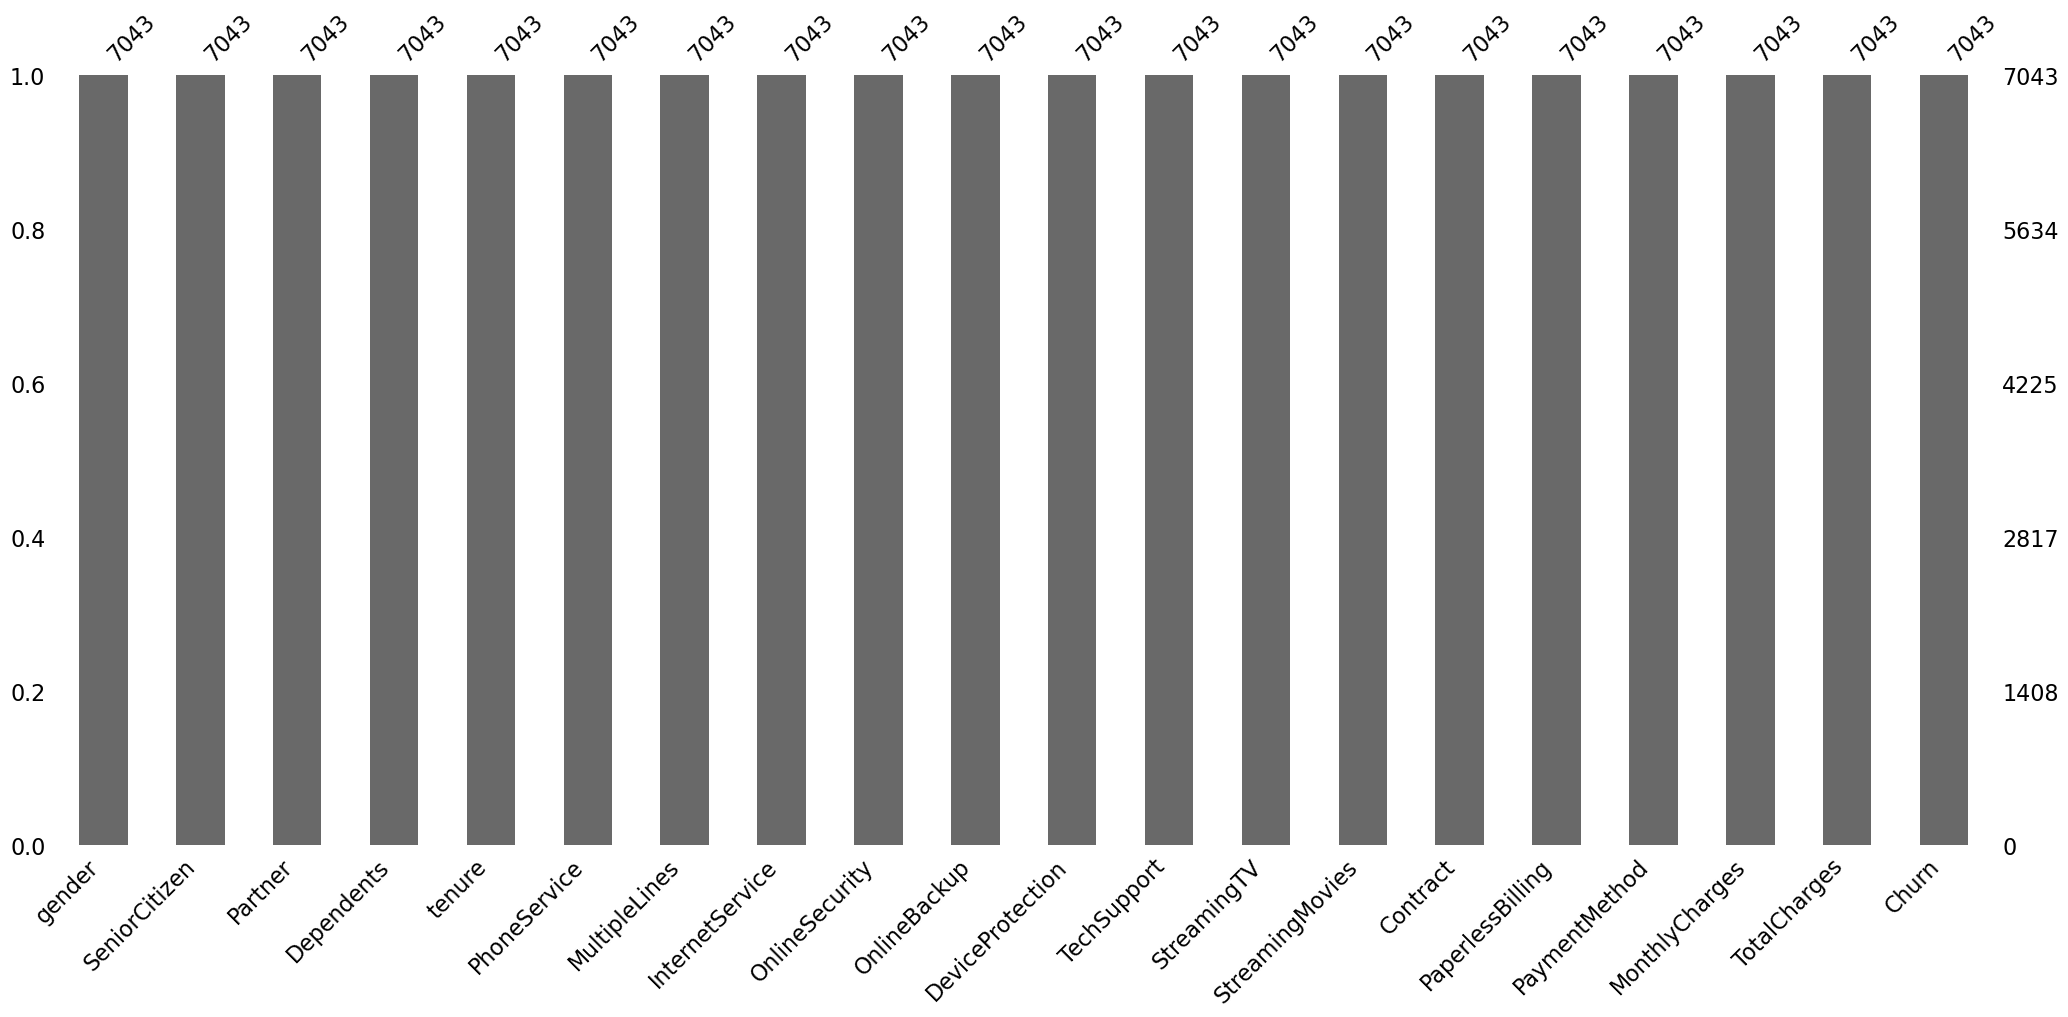

In [22]:
# confirmation of no missing data after fillind missing values

msno.bar(df);

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [24]:
# categorical Table : Confirm  effect on adjustment
categorical_df = df.select_dtypes(include = "object", exclude = "float",)

categorical_df.head()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes


In [25]:
# numerical Table : Confirm  effect on adjustment
numerical_df = df.select_dtypes( exclude = "object")

numerical_df.head(3)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15


### Sorting Duplicate Data

In [27]:
# check duplicates 
df.duplicated().sum()

22

In [28]:
# drop duplicate data 
df = df.drop_duplicates()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 
 17  

In [29]:
#The data is clean and ready for Exploratory Data Analysis 

## Exploratory Data Analysis 

### Numerical Analysis

In [31]:
# Numerical Dataset 
numerical_df.head(3)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15


In [32]:
# Check statistics for the numerical variables 

numerical_df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.000,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.000,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.500,70.35,89.85,118.75
TotalCharges,7043.0,2283.300441,2265.000258,18.80,402.225,1400.55,3786.60,8684.80


In [33]:
# Check statistics for the Categorical variables 

df.describe(include = 'object').T

,count,unique,top,freq
gender,7021,2,Male,3541
Partner,7021,2,No,3619
Dependents,7021,2,No,4911
PhoneService,7021,2,Yes,6339
MultipleLines,7021,3,No,3368
InternetService,7021,3,Fiber optic,3090
OnlineSecurity,7021,3,No,3490
OnlineBackup,7021,3,No,3080
DeviceProtection,7021,3,No,3087
TechSupport,7021,3,No,3465


### Numerical Univariate analysis

In [35]:
# Convert the columns to a list 
numerical_cols = numerical_df.columns.to_list()
numerical_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

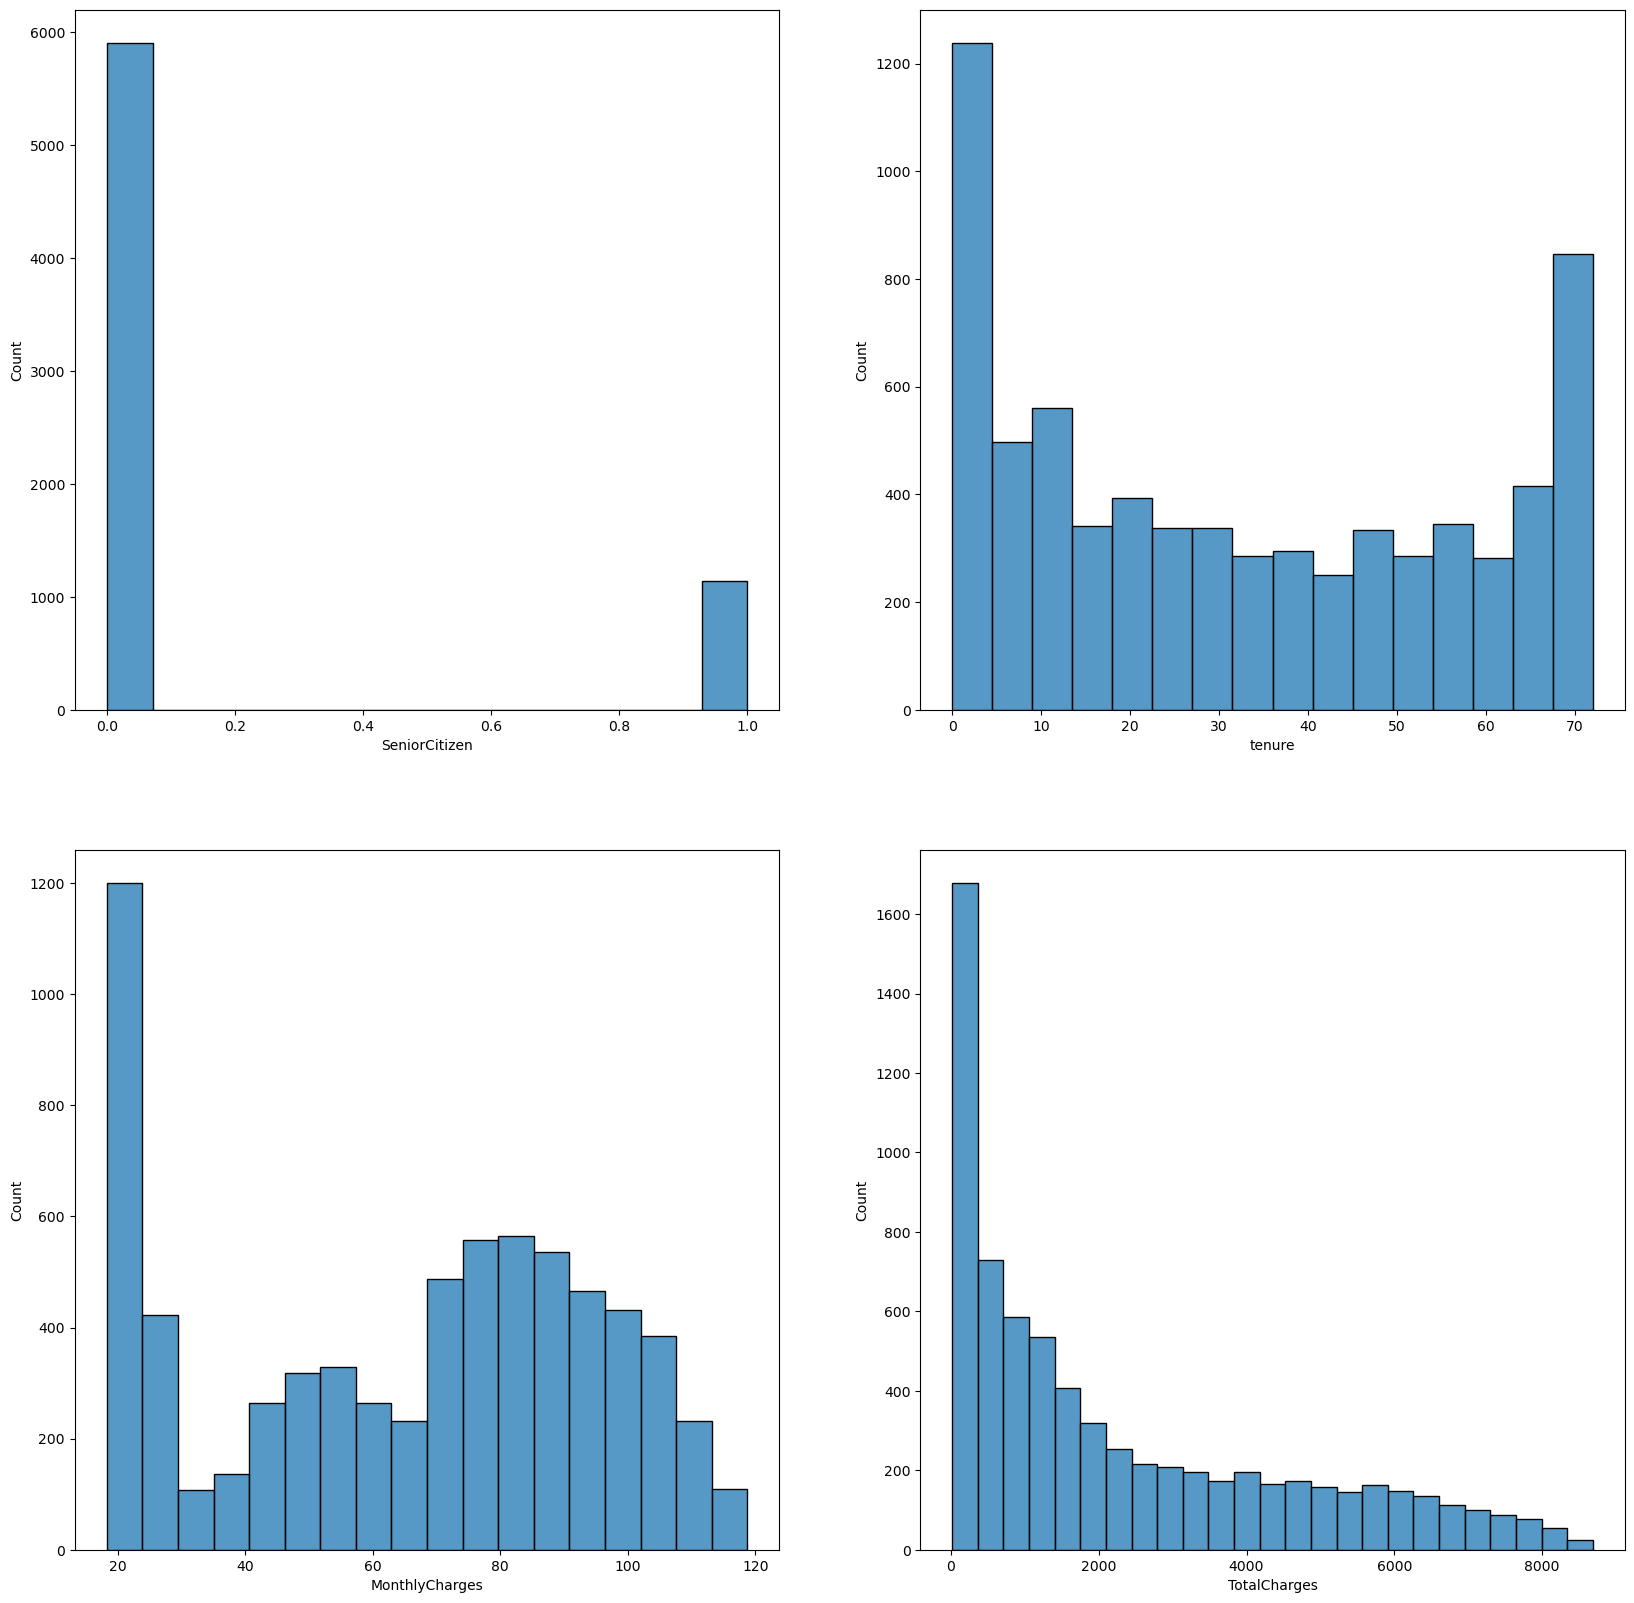

In [36]:
# Histogram of all numerical variables to get a clear picture of the distribution.

fig, axes = plt.subplots ( nrows=2 , ncols= 2, figsize = (20,20))

position = axes.flatten()

for index, name_of_feature in enumerate (numerical_cols):
    sns.histplot( data = numerical_df[name_of_feature] , ax = position[index])

plt.tight_layout
plt.show;

Senior Citizen :
The histogram shows the distribution of the SeniorCitizen variable. Most customers are not senior citizens (coded as 0), while a smaller percentage are senior citizens (coded as 1). The company has a much larger non-senior citizen customer base. This distribution suggests that any analysis or marketing strategies targeting senior citizens will focus on a smaller segment of the customer base.

Tenure:
The tenure distribution is interesting, with peaks at both very low (near 0) and very high (near 70) tenures. This could indicate a mix of new customers and long-term loyal customers, with fewer customers in the mid-range tenure. Customers either leave early (low tenure) or stay for a long time (high tenure). The sharp drop in mid-tenure customers suggests that the company may be losing customers during their early interactions.

Monthly Charges:
The distribution of MonthlyCharges shows a relatively uniform spread, though there is a noticeable spike at the low end. Many customers are paying low monthly charges, but there is also a significant number paying higher charges. The distribution indicates a diverse customer base, with both low-paying and high-paying customers. Customers with low monthly charges may represent more basic service plans, while high monthly charges may indicate customers with more premium services.

Total Charges:
The TotalCharges histogram is right-skewed, showing that most customers have relatively low total charges, while a few have very high total charges. This is expected since total charges are likely correlated with tenure and monthly charges. Newer customers or those with low tenure likely have lower total charges. The right-skew suggests that long-term, high-paying customers are fewer but valuable.


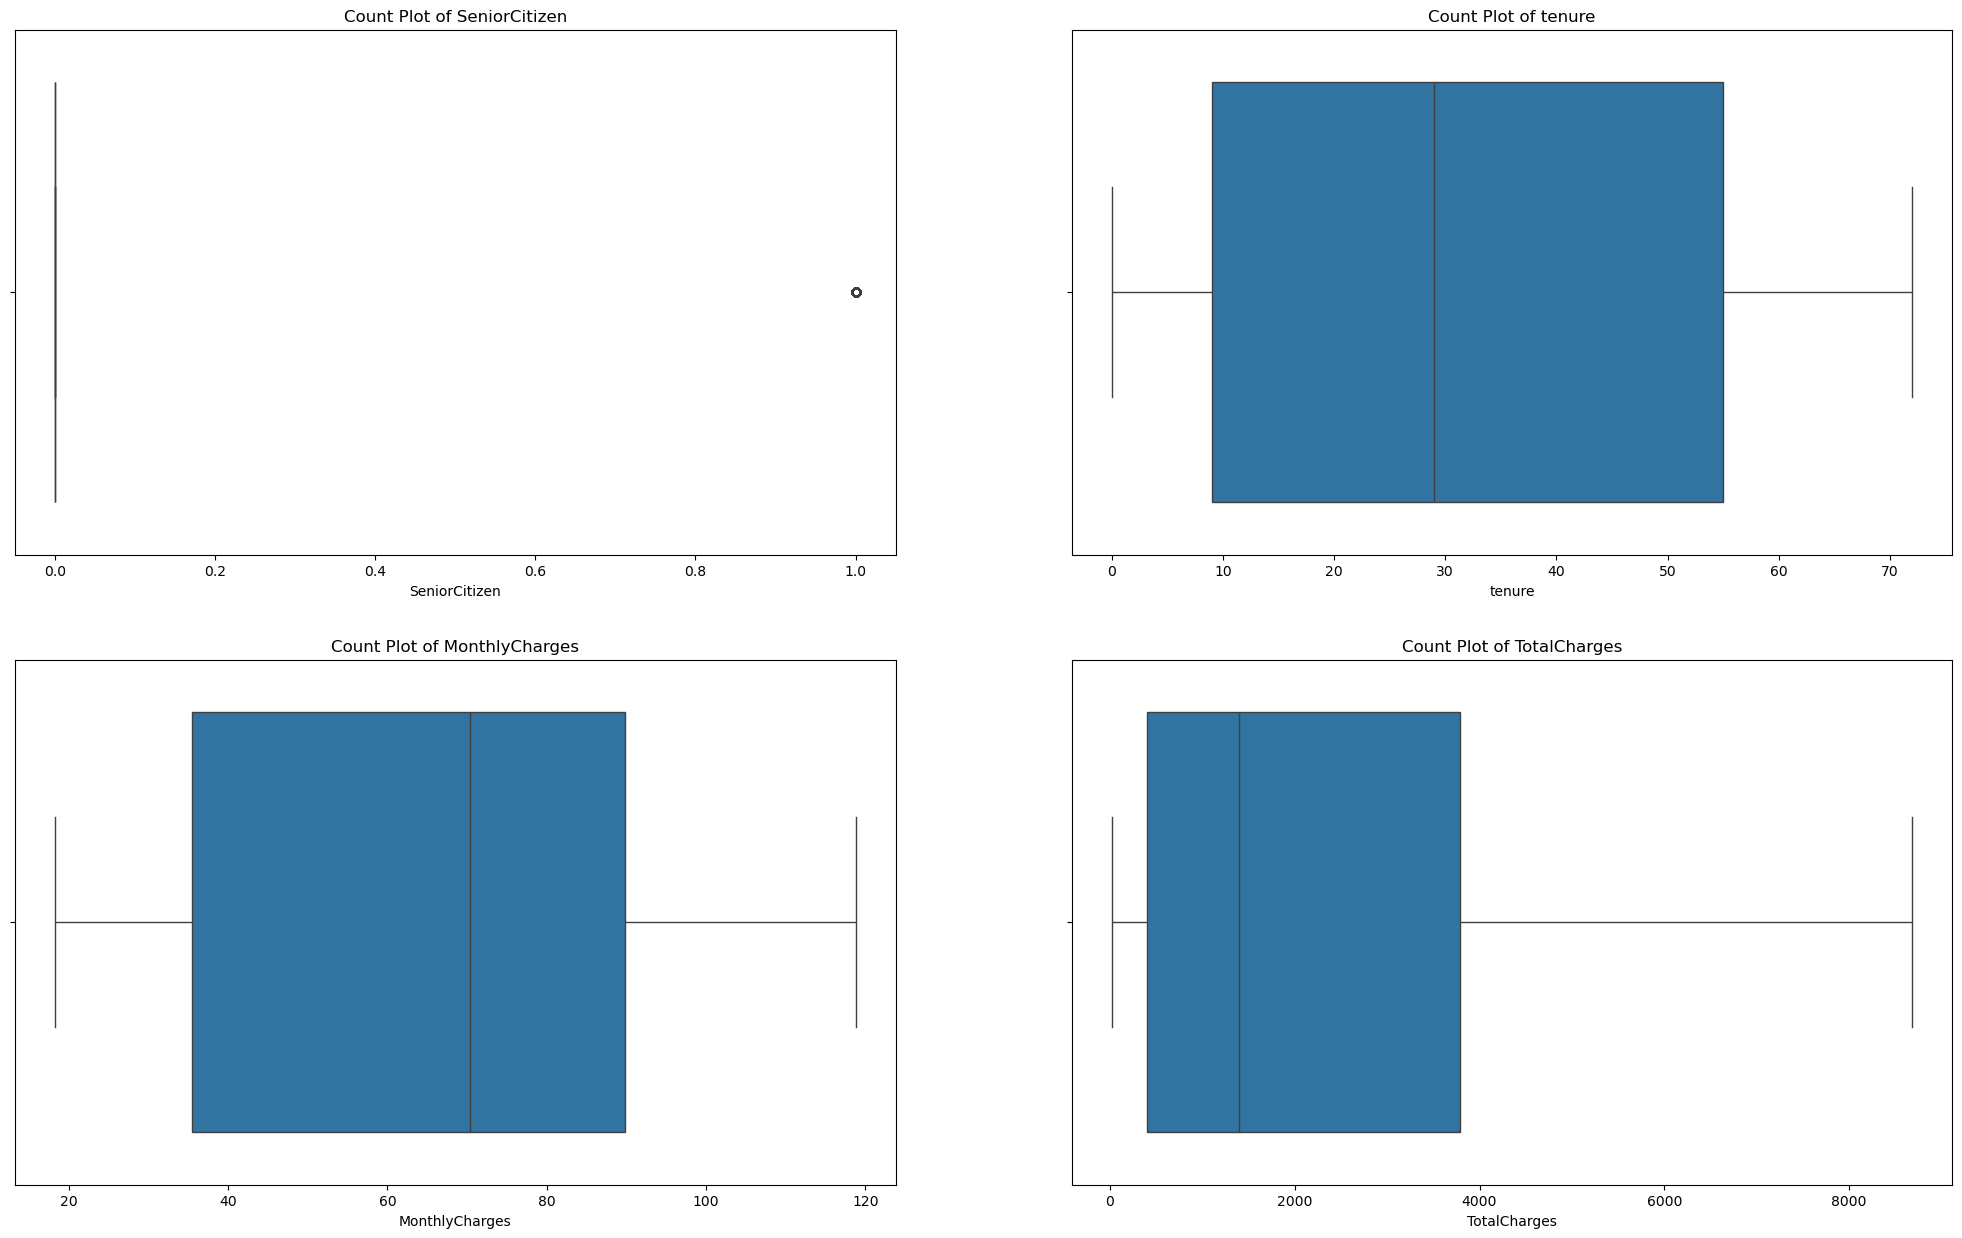

In [38]:
# Checking the box plots visualisation for numerical variables. 

fig, axes = plt.subplots( ncols =2, nrows=2, figsize = (25,15))

sns.boxplot(x="SeniorCitizen", data=numerical_df, ax =axes[0,0])
axes[0,0].set_title(f'Count Plot of {"SeniorCitizen"}')

sns.boxplot(x="tenure", data=numerical_df, ax=axes[0,1] )
axes[0,1].set_title(f'Count Plot of {"tenure"}')

sns.boxplot(x="MonthlyCharges", data=numerical_df, ax=axes[1,0] )
axes[1,0].set_title(f'Count Plot of {"MonthlyCharges"}')

sns.boxplot(x="TotalCharges", data=numerical_df, ax=axes[1,1] )
axes[1,1].set_title(f'Count Plot of {"TotalCharges"}')


plt.tight_layout
plt.show()

Senior Citizen:
The box plot doesn't provide much detail beyond confirming the heavy skew toward non-senior citizens.

Tenure:
The box plot of tenure shows that most customers have a tenure between 10 and 60 months. The median tenure is around 30 months, and there are no significant outliers in the data.

MonthlyCharges:
The MonthlyCharges box plot reveals that most customers are paying between 40 and 90 dollars in monthly charges, with the median around $70. There are no extreme outliers, which suggests the monthly charges are fairly consistent across the customer base.

TotalCharges:
The TotalCharges box plot shows that most customers have total charges between 1,000 and 5,000 dollars, with a few outliers on the higher end (above 8,000 dollars). The median total charge is around $3,000. It's clear that the longer-term customers have accumulated higher charges


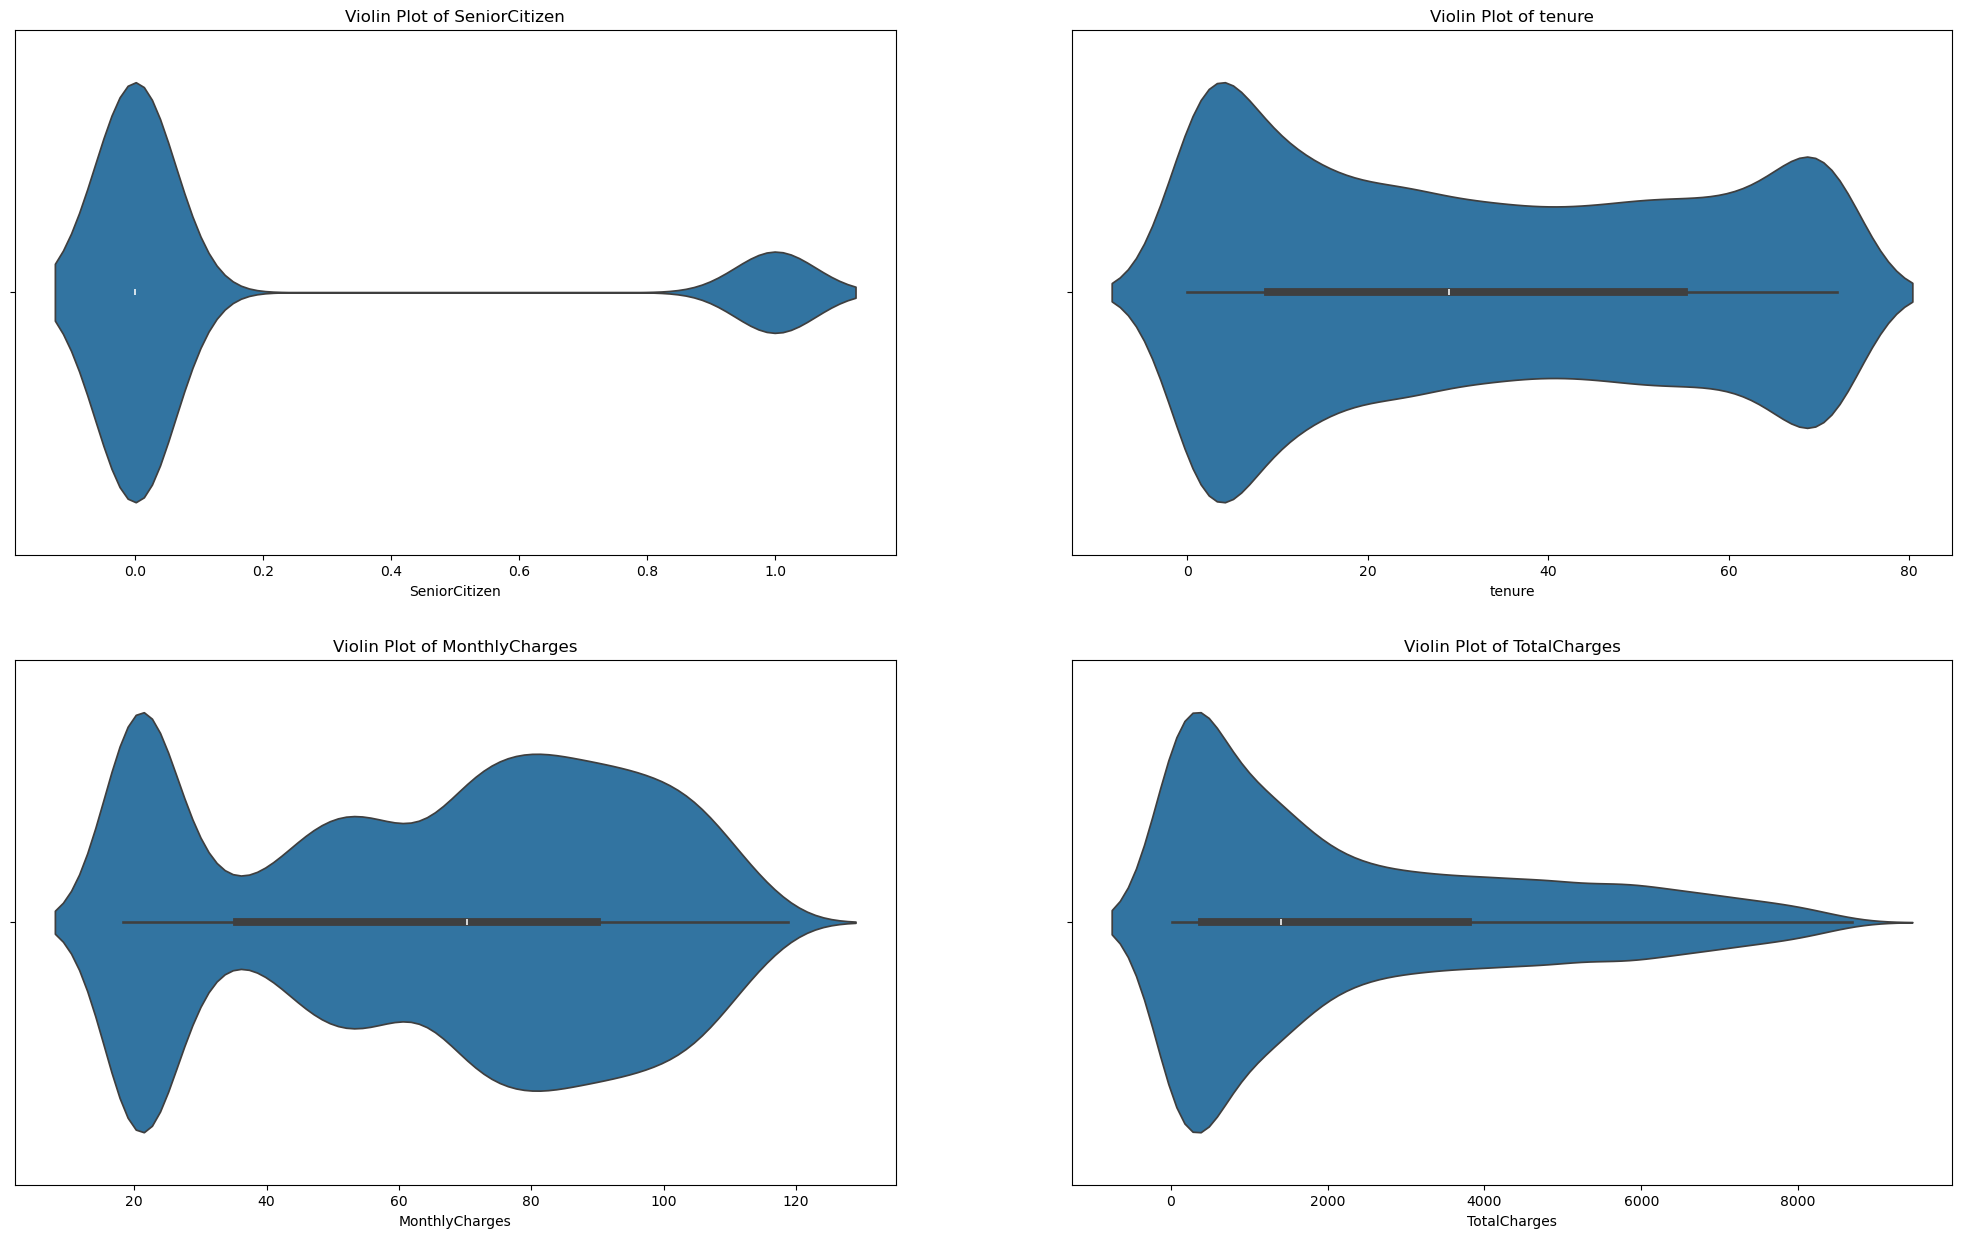

In [40]:
# Checking the Violin  plots visualisation for numerical variables. 

fig, axes = plt.subplots( ncols =2, nrows=2, figsize = (25,15))

sns.violinplot(x="SeniorCitizen", data=numerical_df, ax =axes[0,0])
axes[0,0].set_title(f'Violin Plot of {"SeniorCitizen"}')

sns.violinplot(x="tenure", data=numerical_df, ax=axes[0,1] )
axes[0,1].set_title(f'Violin Plot of {"tenure"}')

sns.violinplot(x="MonthlyCharges", data=numerical_df, ax=axes[1,0] )
axes[1,0].set_title(f'Violin Plot of {"MonthlyCharges"}')

sns.violinplot(x="TotalCharges", data=numerical_df, ax=axes[1,1] )
axes[1,1].set_title(f'Violin Plot of {"TotalCharges"}')


plt.tight_layout
plt.show()

Senior Citizen :
The violin plot shows a sharp peak for non-senior citizens ( Value 0), with a smaller, narrower distribution for senior citizens ( Value 1). 
This again highlights the significant imbalance in the dataset where most customers are non-senior citizens.

Tenure:
It reveals that there are many customers with very short tenures and another large group with very long tenures, with fewer in between. This matches the earlier insights that some customers either leave early or stay long-term.

MonthlyCharges :
The MonthlyCharges plot shows a fairly uniform distribution with some concentration at the lower end of the scale and some variation around the middle (between 60 to 100 dollars). The tail at the high end represents high-paying customers.

TotalCharges:
he TotalCharges plot shows that most customers have lower total charges, but there is a long tail for customers with higher total charges. This suggests that most customers have been with the company for a shorter period, while a few have accumulated larger bills over time

### Numerical Bivariate Analysis

In [43]:
numerical_df.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

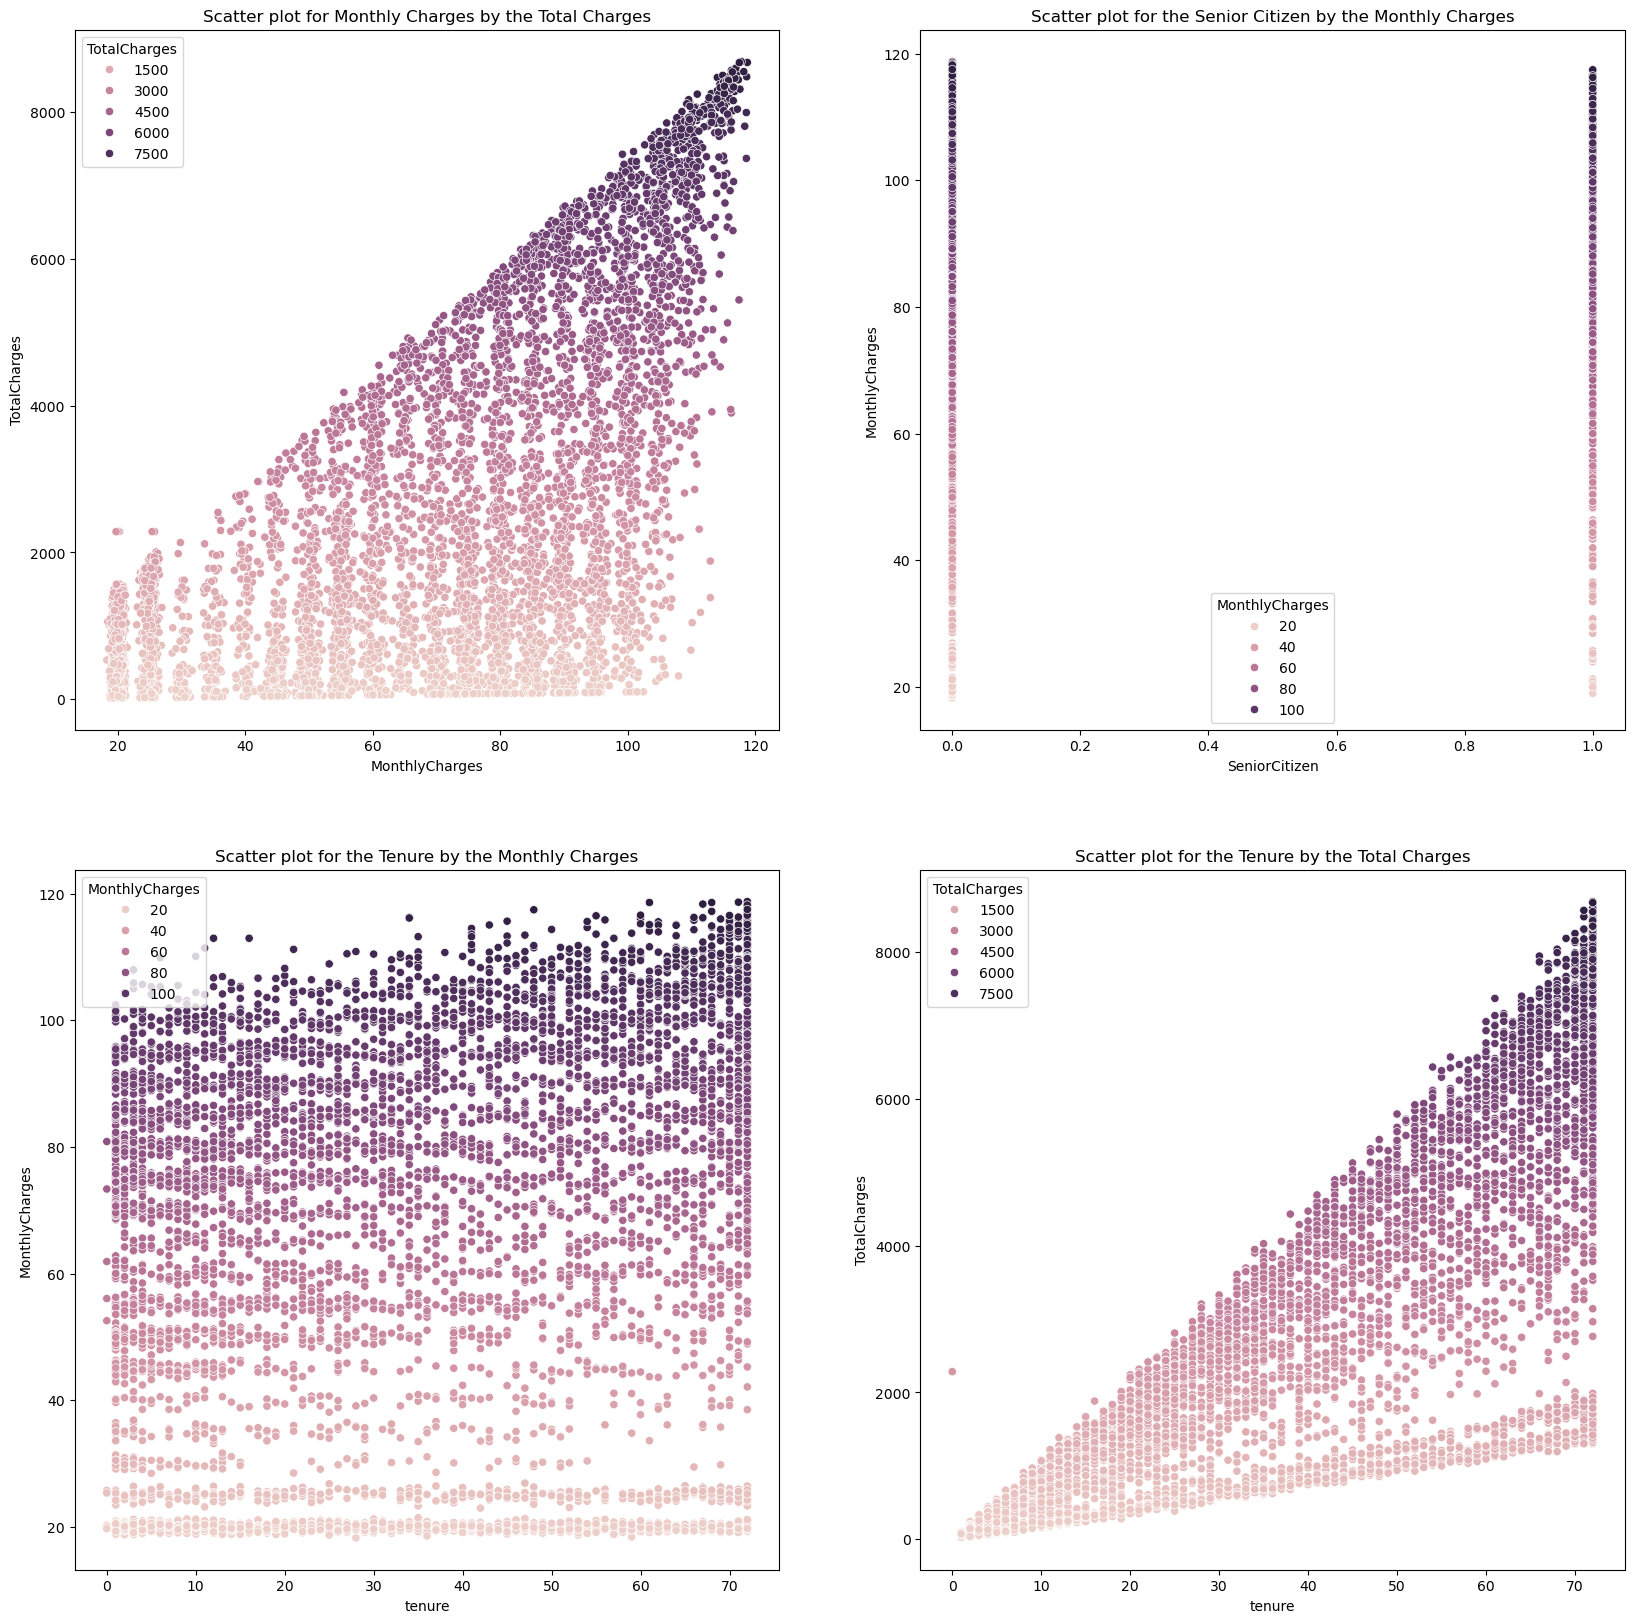

In [44]:
fig, axes = plt.subplots (nrows=2 , ncols=2 ,figsize = (20,20))

sns.scatterplot( x= "MonthlyCharges", y='TotalCharges' , data=numerical_df, hue = 'TotalCharges', ax=axes[0,0] ) 
axes[0,0].set_title("Scatter plot for Monthly Charges by the Total Charges")


sns.scatterplot( x= "SeniorCitizen", y='MonthlyCharges' , data=numerical_df, hue = 'MonthlyCharges', ax=axes[0,1])
axes[0,1].set_title("Scatter plot for the Senior Citizen by the Monthly Charges")


sns.scatterplot( x= "tenure", y='MonthlyCharges' , data=numerical_df, hue = 'MonthlyCharges', ax=axes[1,0])
axes[1,0].set_title("Scatter plot for the Tenure by the Monthly Charges")

sns.scatterplot( x= "tenure", y='TotalCharges' , data=numerical_df, hue = 'TotalCharges', ax=axes[1,1])
axes[1,1].set_title("Scatter plot for the Tenure by the Total Charges");


Monthly Charges vs. Total Charges:
This scatter plot shows a strong linear relationship between MonthlyCharges and TotalCharges. As expected, customers who pay higher monthly charges
tend to accumulate higher total charges over time.There are a few deviations that could be due to customers who haven’t been with the company for long but have higher monthly charges.

Senior Citizen by Monthly Charges:
This plot compares SeniorCitizen status with MonthlyCharges but there doesn’t appear to be a significant difference in monthly charges between the two groups. Senior citizens and non-senior citizens have a similar distribution of monthly charges, suggesting that age does not play a large role in the type of service or pricing customers choose.

Tenure by Monthly Charges:
This plot shows the relationship between tenure and MonthlyCharges. Interestingly, the MonthlyCharges are spread evenly across customers with both short and long tenure, indicating that pricing is not directly tied to how long someone has been a customer. Customers with shorter tenures can be found across all pricing tiers, suggesting that customers on more expensive plans do not necessarily stay longer. This could indicate that higher charges do not always equate to longer customer retention.

Tenure by Total Charges:
This plot shows a strong linear relationship between tenure and TotalCharges, which makes sense because customers who have stayed longer will have accumulated more total charges.There are a few customers with longer tenure but relatively low total charges, which could indicate a need for deeper analysis into why these customers are paying less over time.

#### Numerical Multivariate Analysis

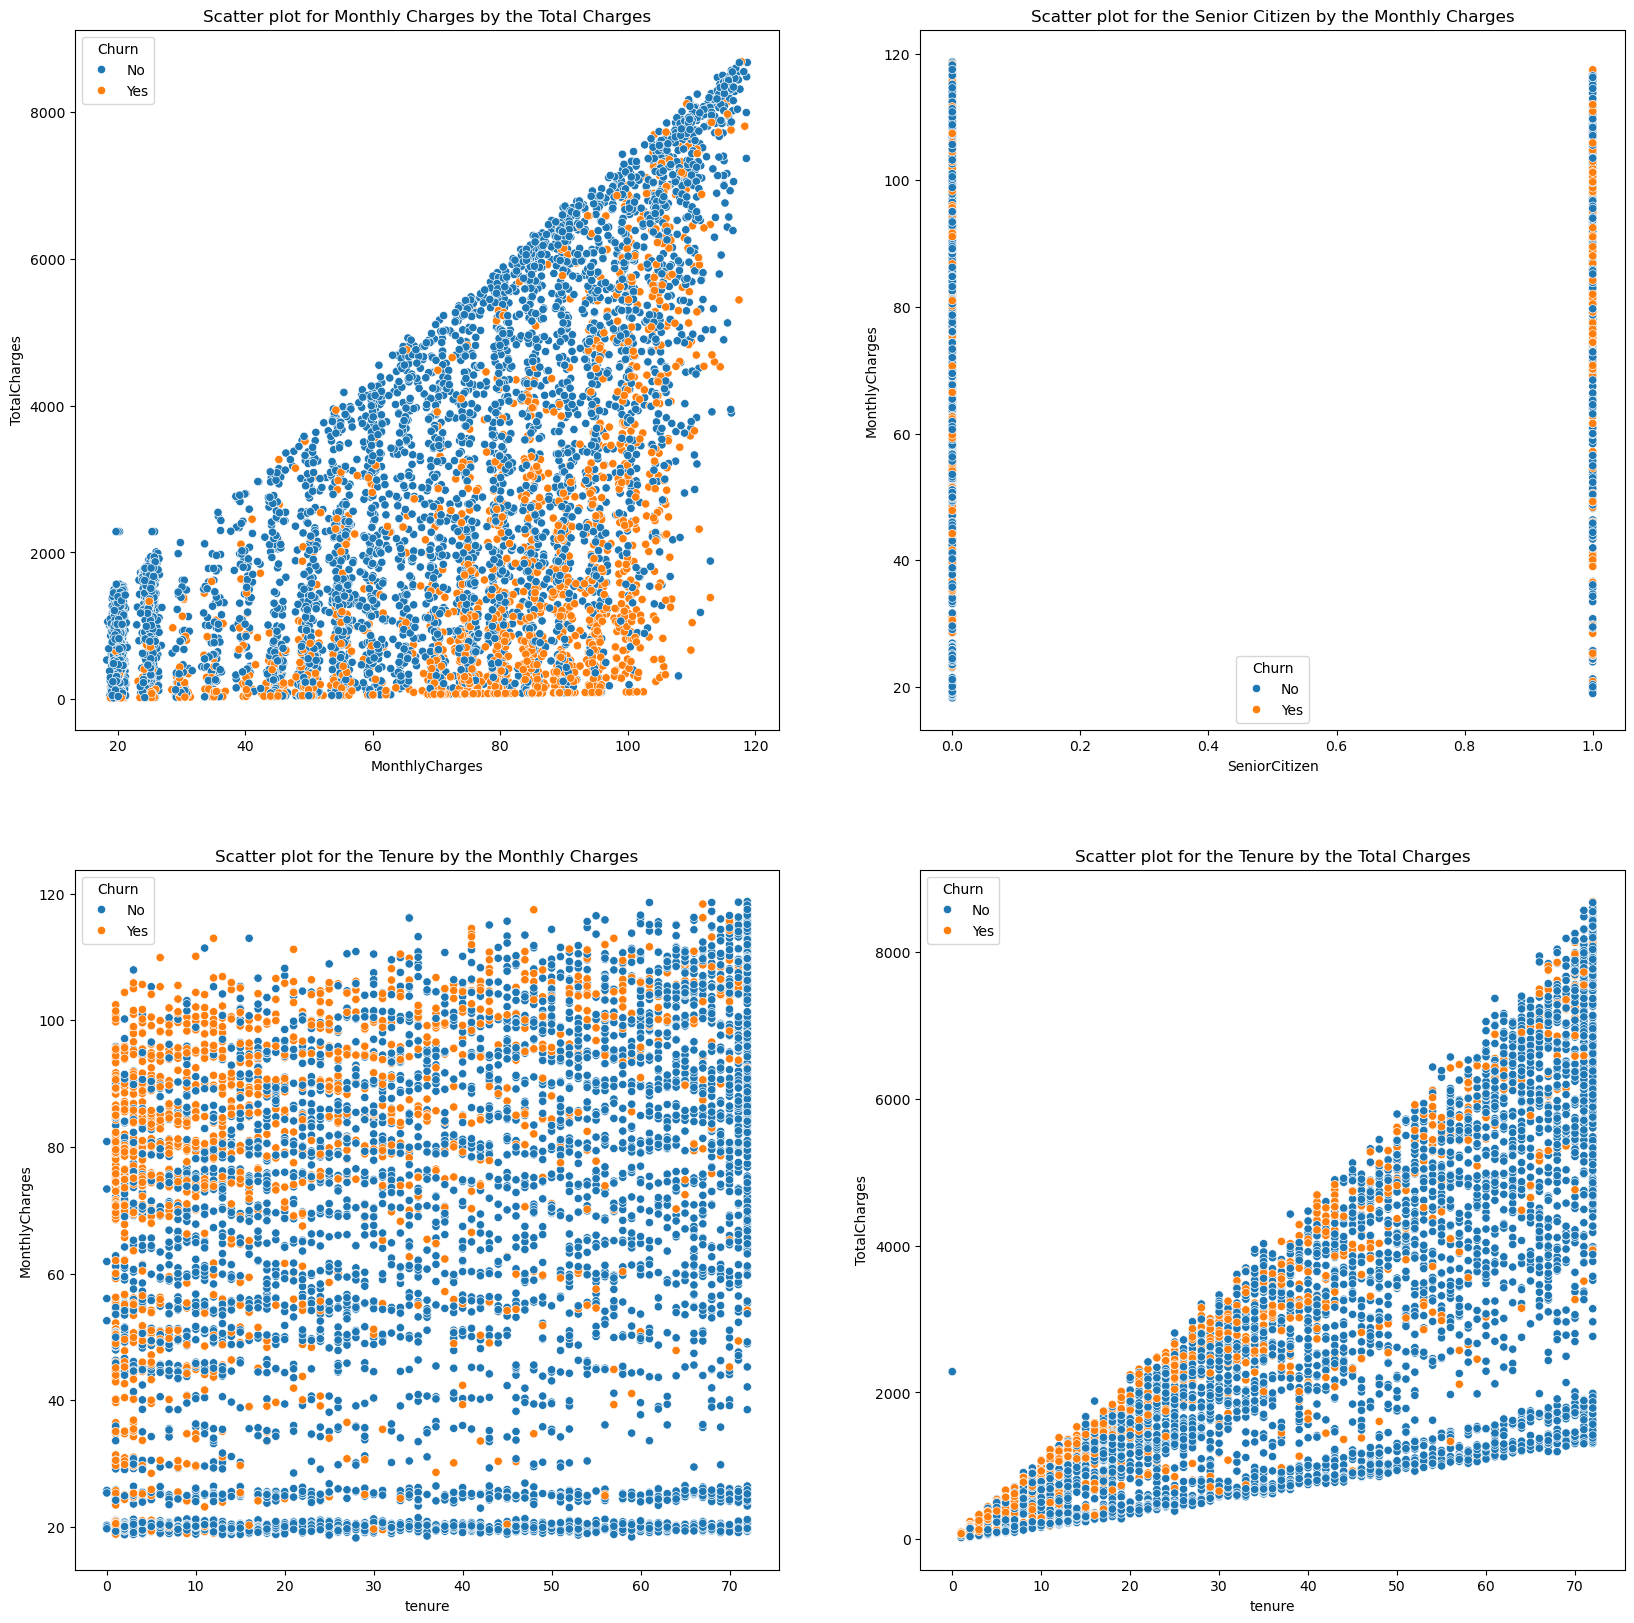

In [47]:
fig, axes = plt.subplots (nrows=2 , ncols=2 ,figsize = (20,20))

sns.scatterplot( x= "MonthlyCharges", y='TotalCharges' , data=df, hue = 'Churn', ax=axes[0,0] ) 
axes[0,0].set_title("Scatter plot for Monthly Charges by the Total Charges")


sns.scatterplot( x= "SeniorCitizen", y='MonthlyCharges' , data=df, hue = 'Churn', ax=axes[0,1])
axes[0,1].set_title("Scatter plot for the Senior Citizen by the Monthly Charges")


sns.scatterplot( x= "tenure", y='MonthlyCharges' , data=df, hue = 'Churn', ax=axes[1,0])
axes[1,0].set_title("Scatter plot for the Tenure by the Monthly Charges")

sns.scatterplot( x= "tenure", y='TotalCharges' , data=df, hue = 'Churn', ax=axes[1,1])
axes[1,1].set_title("Scatter plot for the Tenure by the Total Charges");

Monthly Charges vs. Total Charges
The color-coding by churn status shows that customers who churn (orange dots) are scattered across different TotalCharges and MonthlyCharges values. However, we can see a higher concentration of churn at higher MonthlyCharges.Customers who pay higher MonthlyCharges seem more likely to churn. This could suggest dissatisfaction with the value they are getting for the price they pay. Value for money.

Senior Citizen by Monthly Charges:
The scatter plot shows that there isn’t a strong relationship between being a senior citizen and MonthlyCharges, nor does being a senior citizen seem to strongly affect churn rates.Churn is evenly distributed between senior and non-senior citizens, indicating that factors other than age are more important in predicting churn.

Tenure by Monthly Charges:
Customers with shorter tenure (under 20 months) and higher MonthlyCharges have a higher likelihood of churning. However, longer-tenure customers (over 60 months) tend to stay, even when paying higher MonthlyCharges. Short-tenure customers with higher monthly charges are more likely to churn. This suggests that newer customers may not perceive enough value in what they are paying for, and thus leave early.

Tenure by Total Charges:
Customers with shorter tenures and lower TotalCharges are more likely to churn, as evidenced by the concentration of orange points in the lower-left part of the plot. Conversely, customers with longer tenures and higher TotalCharges tend to stay (more blue points).  Customers with low TotalCharges and short tenure are at the highest risk of churn, while long-tenure, high-total-charge customers are the most loyal.

 General Recommendations:

Target High-Paying, Short-Tenure Customers: Customers who pay high monthly charges but have been with us for a short time are at a higher risk of churning. It would be beneficial to design specific retention strategies for this group, such as exclusive loyalty programs or personalized offers.

Short-Tenure Retention Strategies: We’ve observed that churn rates are higher for customers with low tenure and low total charges. These customers may need more proactive engagement early on, such as better customer service, discounted rates, or targeted promotional offers to prevent them from leaving.

Senior Citizens: The data shows that senior citizens are not necessarily at a higher risk of churn compared to younger customers. Therefore, age-specific strategies may not be critical unless combined with other factors like pricing or tenure.

### Numerical Data Coorelation




In [51]:
numerical_df.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102395
tenure,0.016567,1.000000,0.247900,0.824757
MonthlyCharges,0.220173,0.247900,1.000000,0.650468
TotalCharges,0.102395,0.824757,0.650468,1.000000


<Axes: >

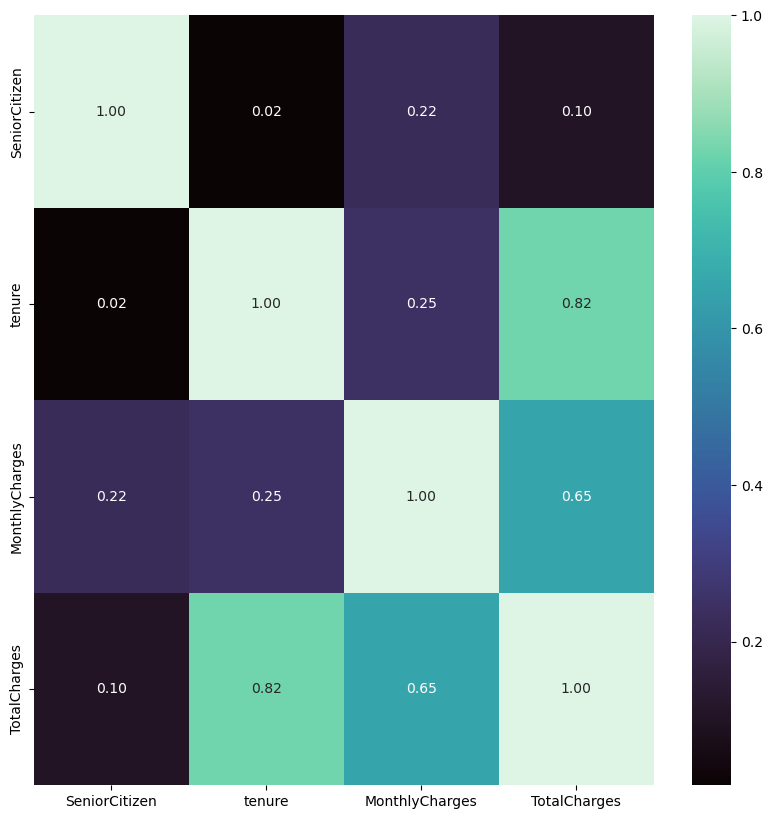

In [52]:
#plot a heatmap to visualise the coorelation

plt.figure(figsize=(10,10))
sns.heatmap( data = numerical_df.corr() , cmap="mako", annot=True , fmt='.2f')

### Categorical Analysis

In [54]:
# analysis of the categorical data variables

categorical_df

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,No
7039,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),No
7040,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
7041,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,Yes


In [55]:
# Investigate the categorical columns
categorical_df.columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [56]:
# Convert them to list 
category_columns = categorical_df.columns.to_list()
category_columns

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [57]:
# inspecting Unique variables in our features 

for feature in category_columns:
    print(feature)
    print(categorical_df[feature].unique())
    print("\n")

gender
['Female' 'Male']


Partner
['Yes' 'No']


Dependents
['No' 'Yes']


PhoneService
['No' 'Yes']


MultipleLines
['No phone service' 'No' 'Yes']


InternetService
['DSL' 'Fiber optic' 'No']


OnlineSecurity
['No' 'Yes' 'No internet service']


OnlineBackup
['Yes' 'No' 'No internet service']


DeviceProtection
['No' 'Yes' 'No internet service']


TechSupport
['No' 'Yes' 'No internet service']


StreamingTV
['No' 'Yes' 'No internet service']


StreamingMovies
['No' 'Yes' 'No internet service']


Contract
['Month-to-month' 'One year' 'Two year']


PaperlessBilling
['Yes' 'No']


PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


Churn
['No' 'Yes']




### Categorical Univariate Analaysis

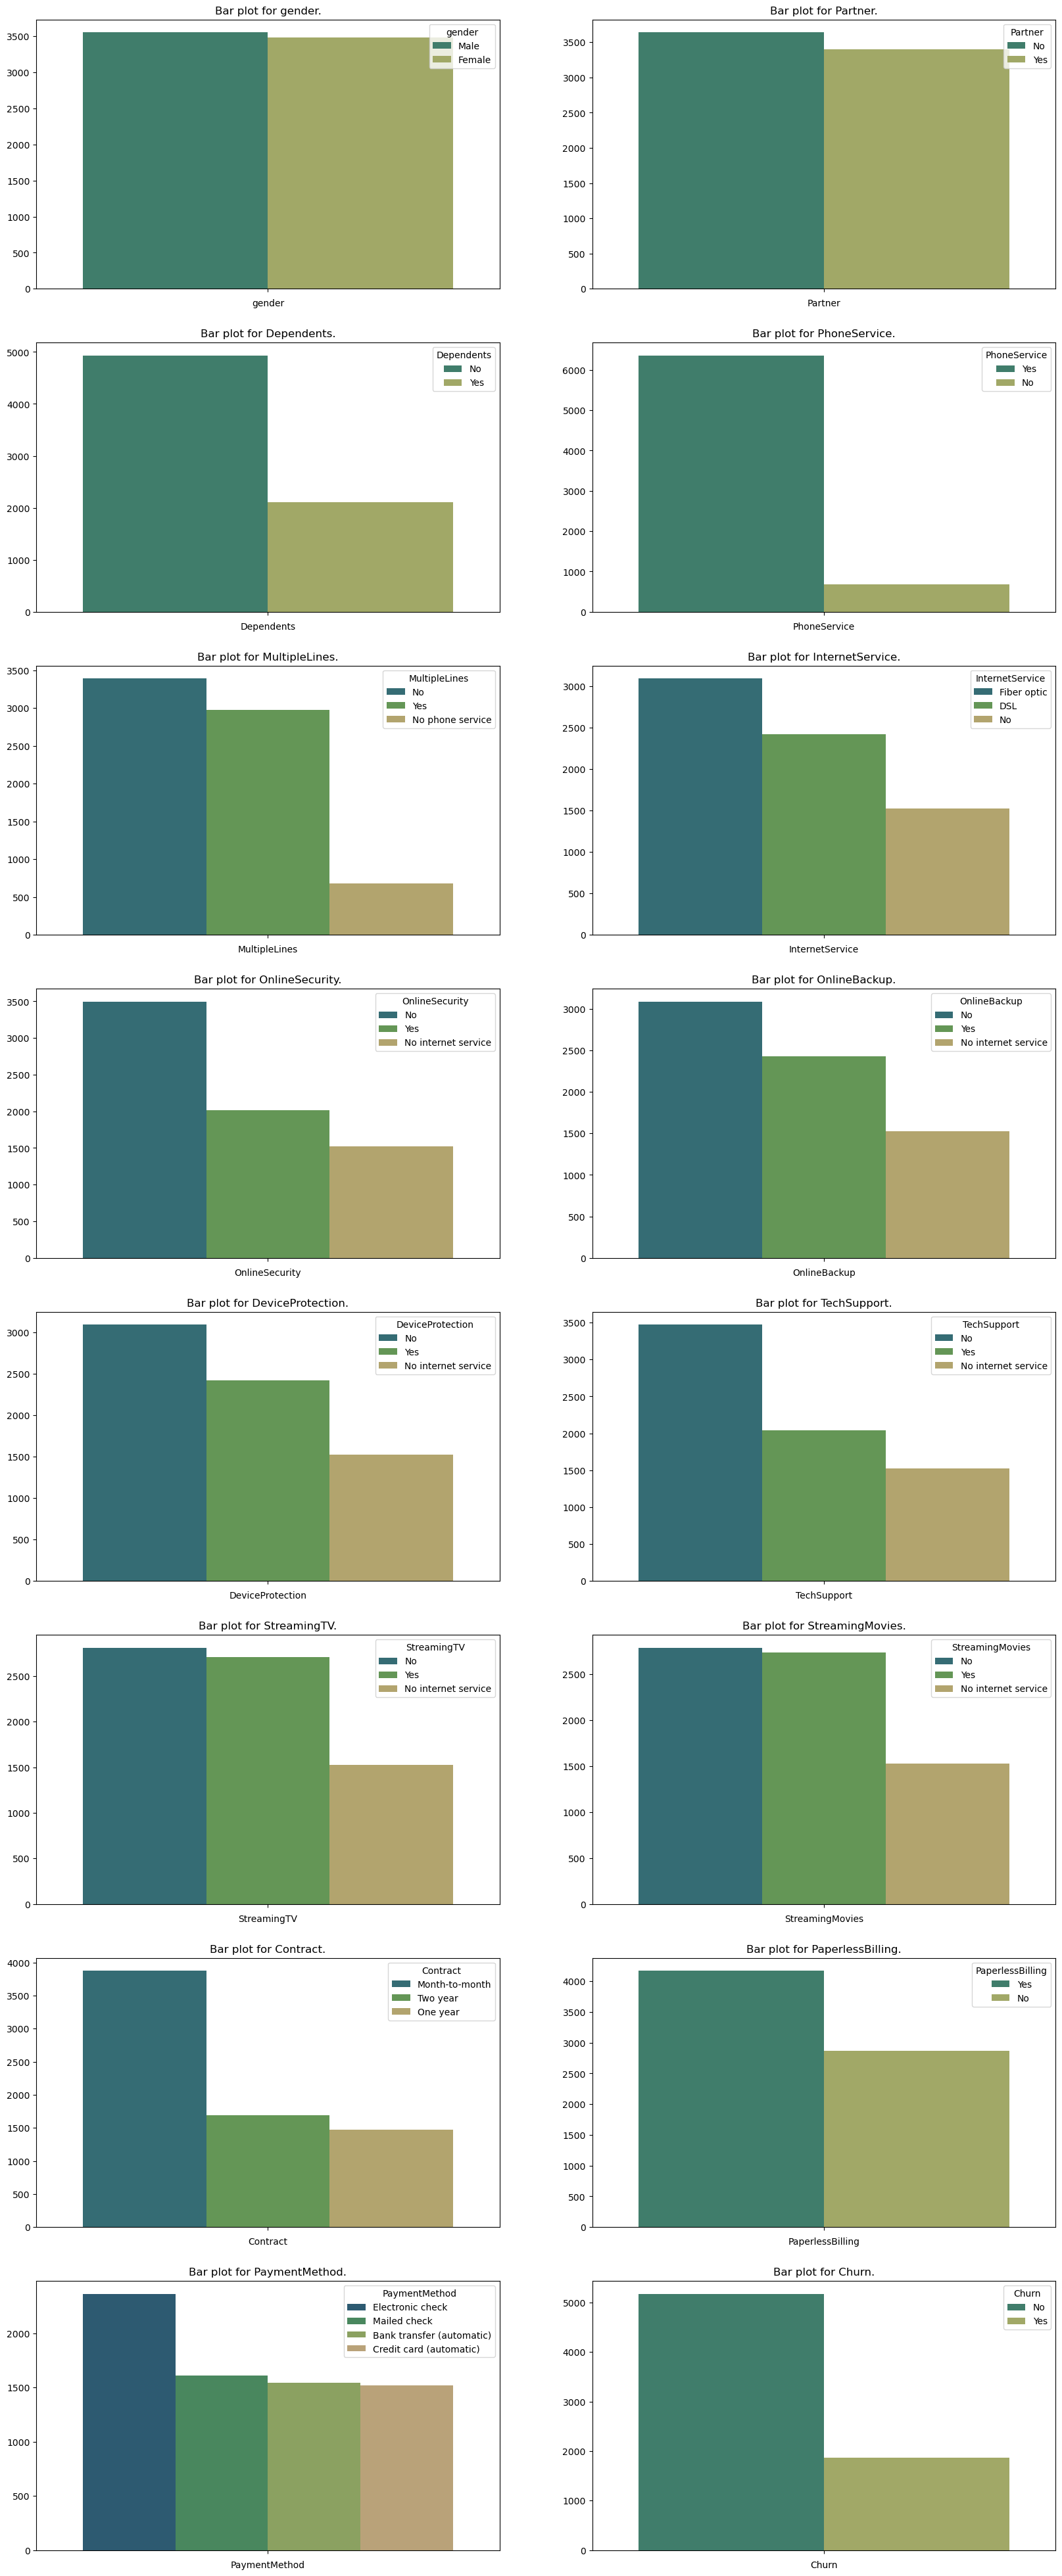

In [59]:
# bar plot visualisation of the features in the categorical variables
fig, axes = plt.subplots ( nrows=8, ncols=2 , figsize = (20,50))

position = axes.flatten()

for index, feature in enumerate(category_columns):
    sns.barplot( hue= categorical_df[feature].value_counts().index , y = categorical_df[feature].value_counts().values, ax = position[index], palette = 'gist_earth')
    position[index].set_title(f'Bar plot for {feature}.')
    position[index].set_xlabel(f'{feature}')

plt.tight_layout
plt.show;


Gender:
The bar plot for gender shows that there is an approximately equal distribution of male and female customers. Since the customer base is evenly split by gender, gender-specific churn strategies may not be necessary unless further analysis shows that one gender is more prone to churn.

Partner:
There are more customers without a partner than those with a partner, but the distribution is relatively even.

Dependents:
Most customers do not have dependents.Since the majority of the customer base does not have dependents, marketing strategies targeting families may not be as effective unless dependents are tied to specific service usage.

PhoneService:
Most customers have phone service.

InternetService:
The bar plot shows that fiber optic is the most common type of internet service, followed by DSL. A notable portion of customers does not have internet service. Fiber optic customers may be the largest segment and thus a critical focus for retention efforts.

MultipleLines:
The majority of customers do not have multiple lines, but there is still a significant group with multiple lines.Customers with multiple lines may represent more valuable accounts for the company.

OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies:
For most of these services, the majority of customers do not subscribe, with fewer customers opting in.

Contract:
The majority of customers are on month-to-month contracts, with fewer on one-year or two-year contracts.Month-to-month contracts may be associated with higher churn rates since customers can leave more easily.

PaperlessBilling:
The majority of customers use paperless billing.Since this is the preferred method, there may not be a need to push paperless billing further.

PaymentMethod:
Electronic checks are the most common payment method, followed by mailed checks, bank transfers, and credit cards.

Churn:
The bar plot shows that more customers stay with the company than churn, but the churn rate is still significant.
    

General Recommendations:

    
Segment Customers for Retention: We need to prioritize retention efforts on customer segments with a higher likelihood of churn, such as those on month-to-month contracts or those using specific payment methods like electronic checks.

Upselling Opportunities: Many customers are not subscribed to services like Online Security, Streaming TV, and Tech Support. By upselling these services, we can increase customer engagement and make it harder for them to leave, thereby reducing churn.

Encourage Long-Term Contracts: Since a significant portion of customers are on month-to-month contracts, offering them discounts or additional perks for switching to longer-term contracts can help stabilize customer retention and lower churn rates.

### Categorical Bivariate  Analysis

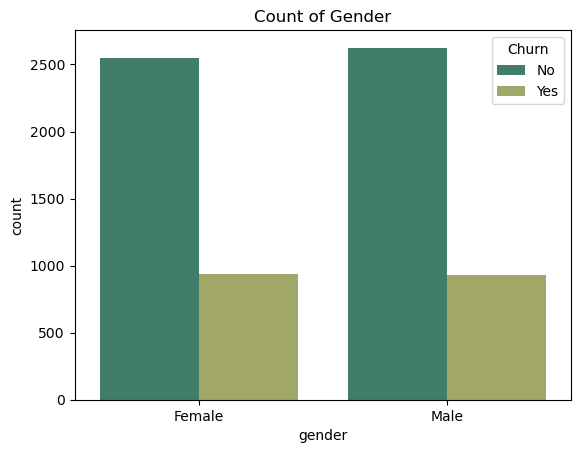

In [62]:
# investigating the churn factor in various variables

sns.countplot( x= "gender" , hue = 'Churn', data = categorical_df , palette = "gist_earth")
plt.title('Count of Gender');


Gender:
The bar plot shows that the distribution of customers by gender is relatively equal. Both male and female customers are represented 
in almost the same numbers. This plot suggests that gender is not a major factor in predicting churn, as the churn rates between male 
and female customers are almost the same.

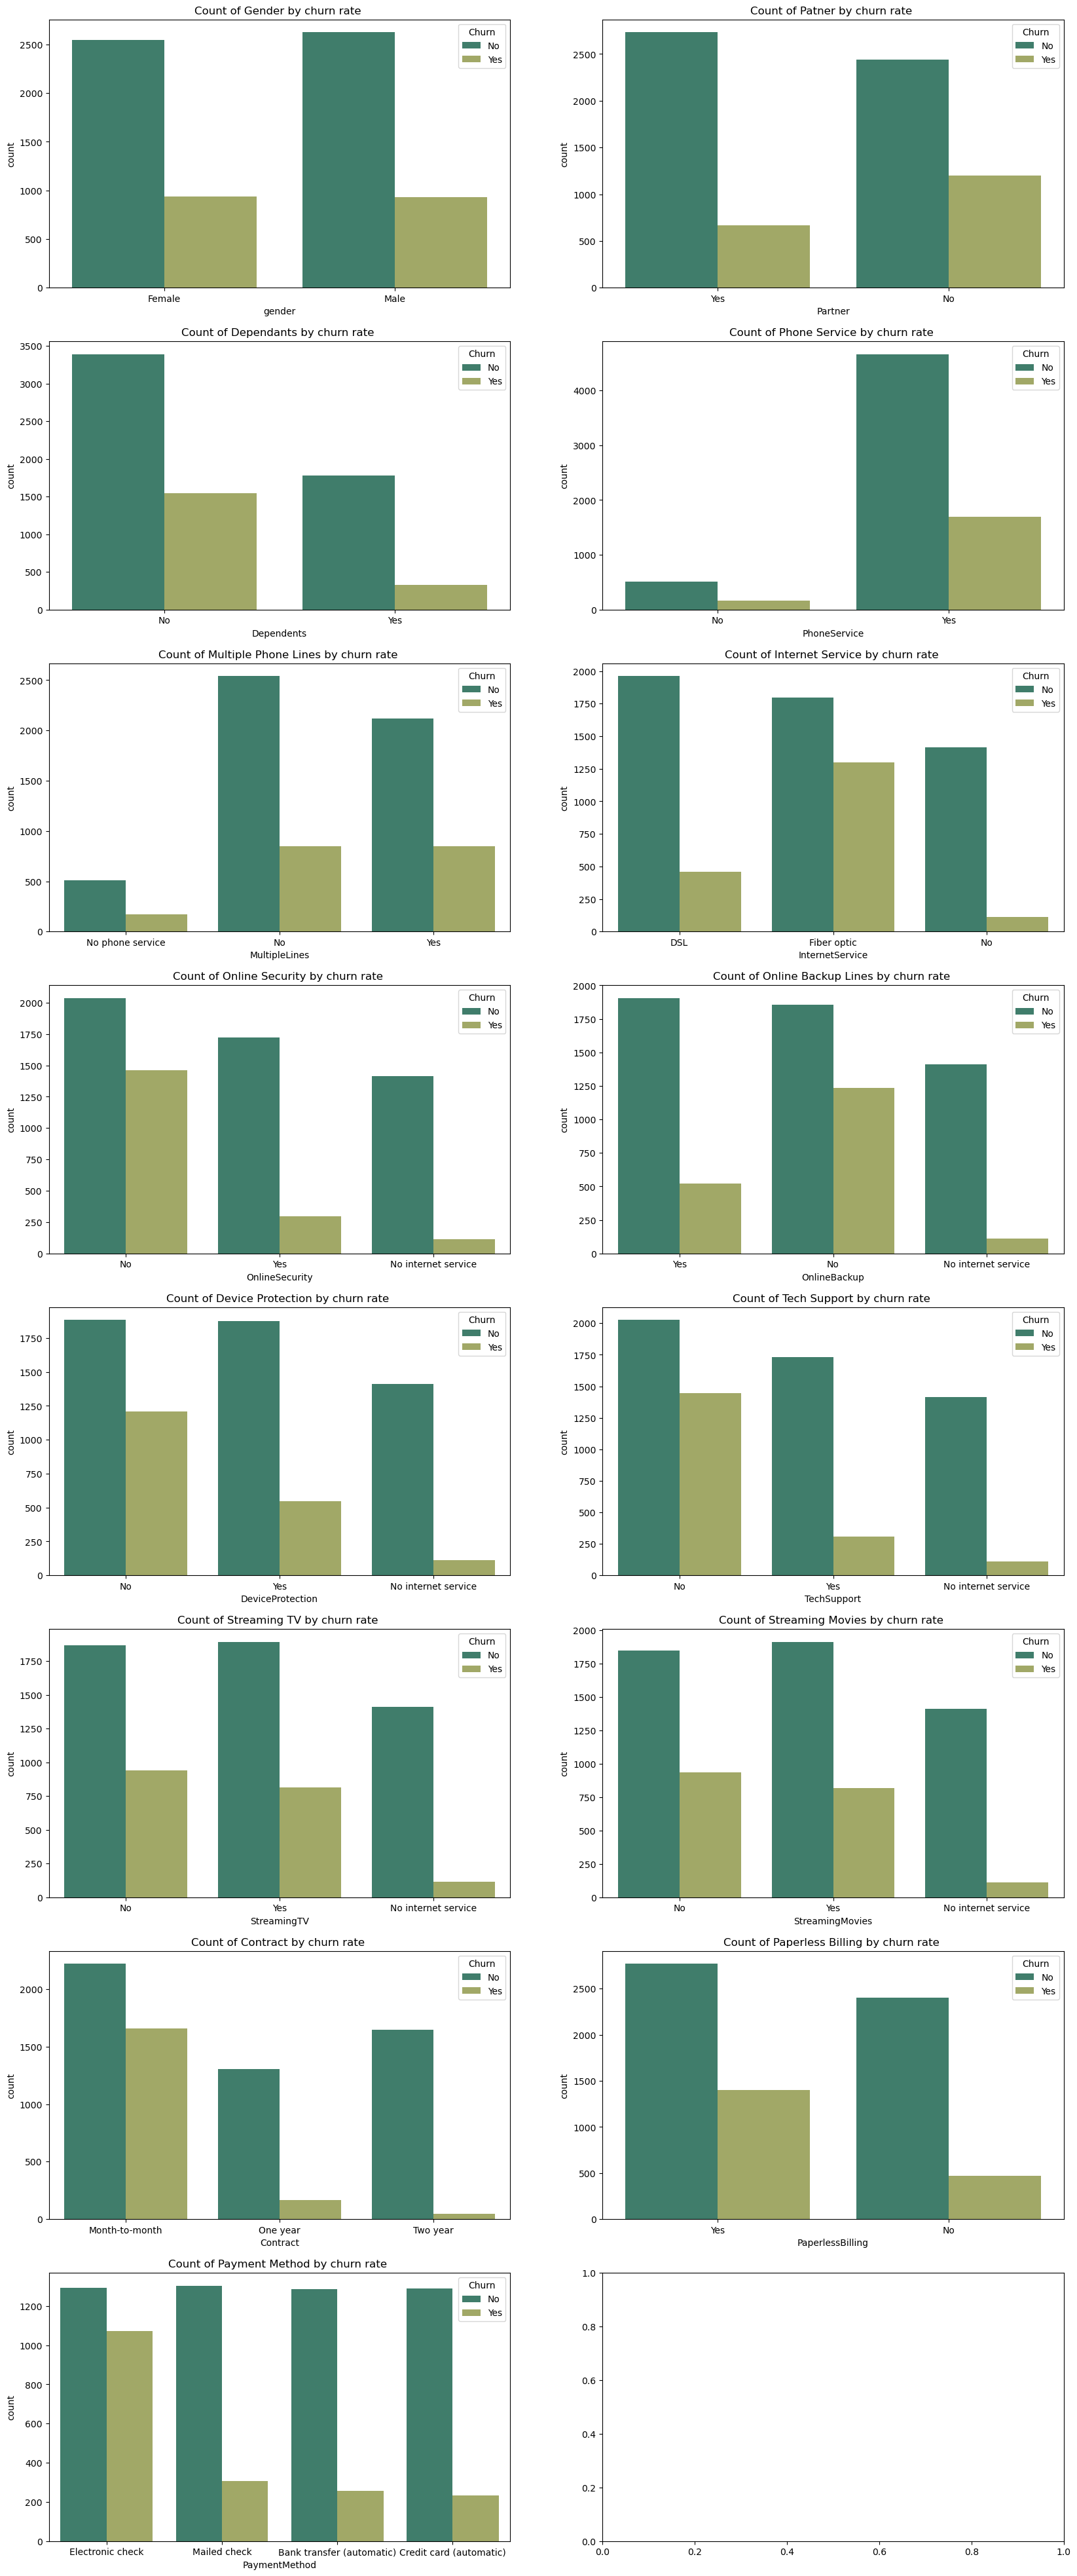

In [344]:
# Bivariate Analysis of the diffrent categorical data

fig, axes = plt.subplots ( nrows=8, ncols=2 , figsize = (20,50))

sns.countplot( x= "gender" , hue ="Churn", data = categorical_df, ax=axes[0,0], palette = 'gist_earth')
axes[0,0].set_title('Count of Gender by churn rate ')

sns.countplot( x= "Partner" , hue ="Churn", data = categorical_df, ax=axes[0,1], palette = 'gist_earth')
axes[0,1].set_title('Count of Patner by churn rate ')

sns.countplot( x= "Dependents" , hue ="Churn", data = categorical_df, ax=axes[1,0], palette = 'gist_earth')
axes[1,0].set_title('Count of Dependants by churn rate ')

sns.countplot( x= "PhoneService" , hue ="Churn", data = categorical_df, ax=axes[1,1], palette = 'gist_earth')
axes[1,1].set_title('Count of Phone Service by churn rate ')

sns.countplot( x= "MultipleLines" , hue ="Churn", data = categorical_df, ax=axes[2,0], palette = 'gist_earth')
axes[2,0].set_title('Count of Multiple Phone Lines by churn rate ')

sns.countplot( x= "InternetService" , hue ="Churn", data = categorical_df, ax=axes[2,1], palette = 'gist_earth')
axes[2,1].set_title('Count of Internet Service by churn rate ')

sns.countplot( x= "OnlineSecurity" , hue ="Churn", data = categorical_df, ax=axes[3,0], palette = 'gist_earth')
axes[3,0].set_title('Count of Online Security by churn rate ')

sns.countplot( x= "OnlineBackup" , hue ="Churn", data = categorical_df, ax=axes[3,1], palette = 'gist_earth')
axes[3,1].set_title('Count of Online Backup Lines by churn rate ')

sns.countplot( x= "DeviceProtection" , hue ="Churn", data = categorical_df, ax=axes[4,0], palette = 'gist_earth')
axes[4,0].set_title('Count of Device Protection by churn rate ')

sns.countplot( x= "TechSupport" , hue ="Churn", data = categorical_df, ax=axes[4,1], palette = 'gist_earth')
axes[4,1].set_title('Count of Tech Support by churn rate ')

sns.countplot( x= "StreamingTV" , hue ="Churn", data = categorical_df, ax=axes[5,0], palette = 'gist_earth')
axes[5,0].set_title('Count of Streaming TV by churn rate ')

sns.countplot( x= "StreamingMovies" , hue ="Churn", data = categorical_df, ax=axes[5,1], palette = 'gist_earth')
axes[5,1].set_title('Count of Streaming Movies by churn rate ')

sns.countplot( x= "Contract" , hue ="Churn", data = categorical_df, ax=axes[6,0], palette = 'gist_earth')
axes[6,0].set_title('Count of Contract by churn rate ')

sns.countplot( x= "PaperlessBilling" , hue ="Churn", data = categorical_df, ax=axes[6,1], palette = 'gist_earth')
axes[6,1].set_title('Count of Paperless Billing by churn rate ')

sns.countplot( x= "PaymentMethod" , hue ="Churn", data = categorical_df, ax=axes[7,0], palette = 'gist_earth')
axes[7,0].set_title('Count of Payment Method by churn rate ')

plt.tight_layout
plt.show;

Gender:
Both male and female customers exhibit a similar distribution in churn. There’s no significant difference in churn rates between genders.

Partner:
Customers who do not have a partner are more likely to churn compared to those with a partner.

Dependents:
Customers without dependents are more likely to churn than those with dependents.

Phone Service:
The majority of customers have phone service, and those without it seem to churn at a higher rate. However, the number of customers without phone service is small.

Multiple Lines:
Customers with multiple phone lines have a slightly lower churn rate compared to those with a single line or no service.

Internet Service:
Customers with fiber optic internet service show a higher churn rate compared to DSL and customers without internet service.

Online Security:
Customers without online security are more likely to churn compared to those with this service.

Online Backup:
Customers without online backup service are more likely to churn compared to those with it.

Device Protection:
Customers without device protection are more likely to churn compared to those with it.

Tech Support :
Customers without tech support are more likely to churn than those with this service.

Streaming TV:
Customers who do not subscribe to streaming TV are more likely to churn.

Streaming Movies:
Customers who do not subscribe to streaming movies are more likely to churn.

Contract :
Month-to-month contract customers are significantly more likely to churn compared to those with one- or two-year contracts.

Paperless Billing:
Customers who use paperless billing are more likely to churn compared to those who do not.

Payment Method :
Customers who use electronic checks have a higher churn rate compared to those who use bank transfers, credit cards, or mailed checks.



**Recommendations**

Contract Type: One of the key findings is that customers on month-to-month contracts are much more likely to churn. We should prioritize converting these customers to longer-term contracts by offering attractive incentives or discounts to encourage commitment.

Value-Added Services: Services like online security, device protection, and tech support have been linked to lower churn rates. We can drive retention by upselling these services to customers who don’t already have them, positioning them as valuable add-ons that enhance the customer experience.

Payment Method: Customers who use electronic checks have a higher churn rate. Promoting more seamless payment methods, such as automatic credit card payments or bank transfers, could help reduce churn by improving payment convenience and reducing friction.

Partner and Dependent Status: We noticed that customers without partners or dependents are more likely to churn. Tailoring retention strategies or offering services specifically designed for this group could help reduce churn. This might include personalized packages or targeted offers that meet their unique needs.





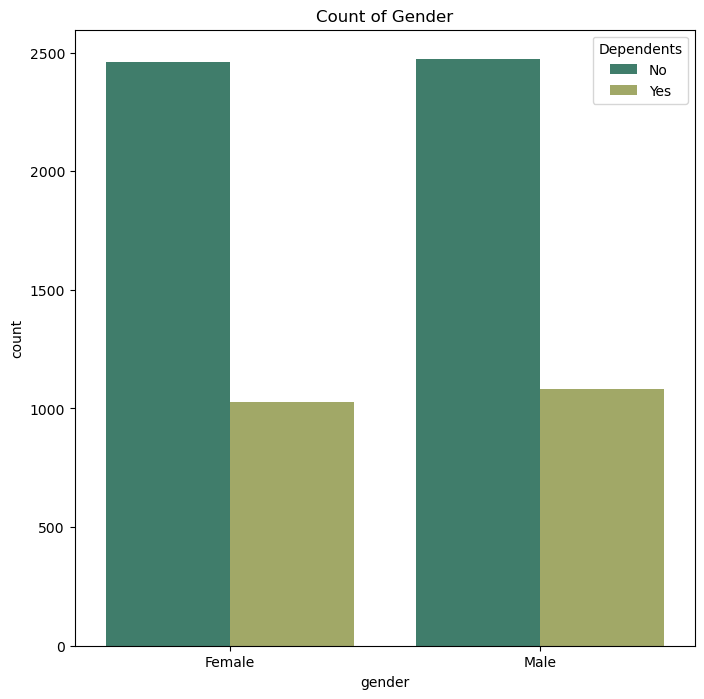

In [66]:
# investigating the gender factor by dependents
plt.figure(figsize = (8,8))
sns.countplot( x= "gender" , hue = 'Dependents', data = categorical_df , palette = "gist_earth")
plt.title('Count of Gender');

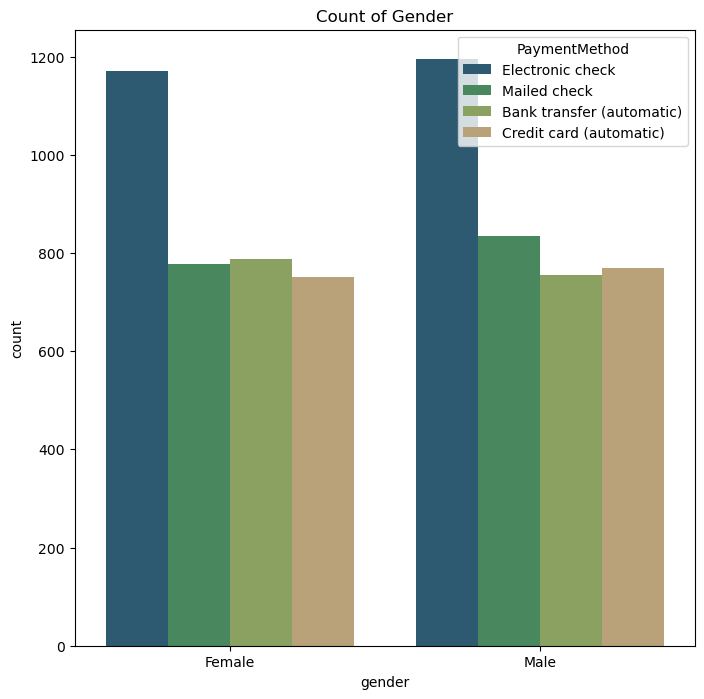

In [67]:
# investigating the gender factor by PaymentMethod

plt.figure(figsize = (8,8))
sns.countplot( x= "gender" , hue = 'PaymentMethod', data = categorical_df , palette = "gist_earth")
plt.title('Count of Gender');

The usage of other payment methods, such as Mailed check, Bank transfer (automatic), and Credit card (automatic), is more evenly distributed across genders, but they are less common than electronic checks.

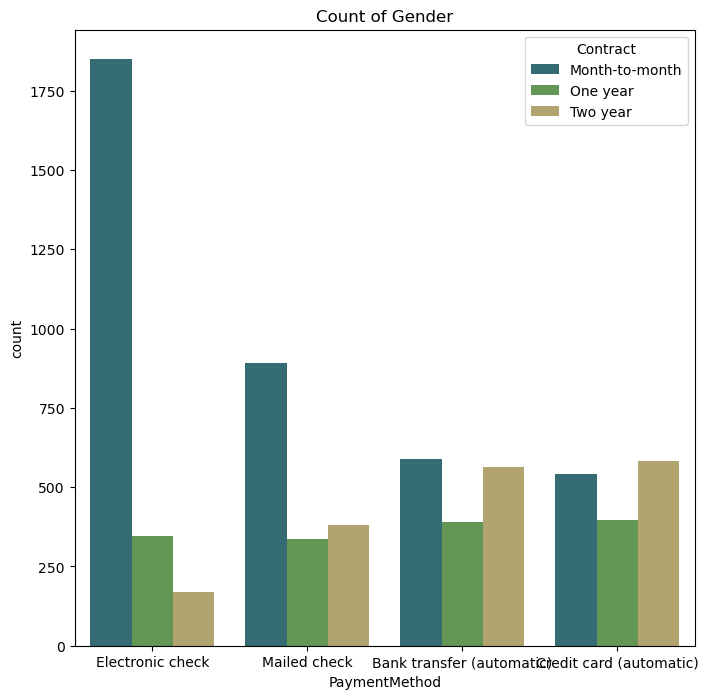

In [69]:
# investigating the Payment Method factor by contract
plt.figure(figsize = (8,8))
sns.countplot( x= "PaymentMethod" , hue = 'Contract', data = categorical_df , palette = "gist_earth")
plt.title('Count of Gender');

1.Electronic Check Users: These customers are the most likely to be on month-to-month contracts, making them more vulnerable to churn. Focus on converting them to automatic payment methods and longer-term contracts.

2.Automatic Payment Users (Bank Transfer/Credit Card): These customers are more stable and tend to sign up for longer-term contracts. Promote these payment methods to other customer groups to increase loyalty.

3.Mailed Check Users: While mailed check users are less likely to be on long-term contracts, there’s still a portion who do commit to one-year or two-year contracts. Focus needs to go to converting these customers to automatic payment methods.

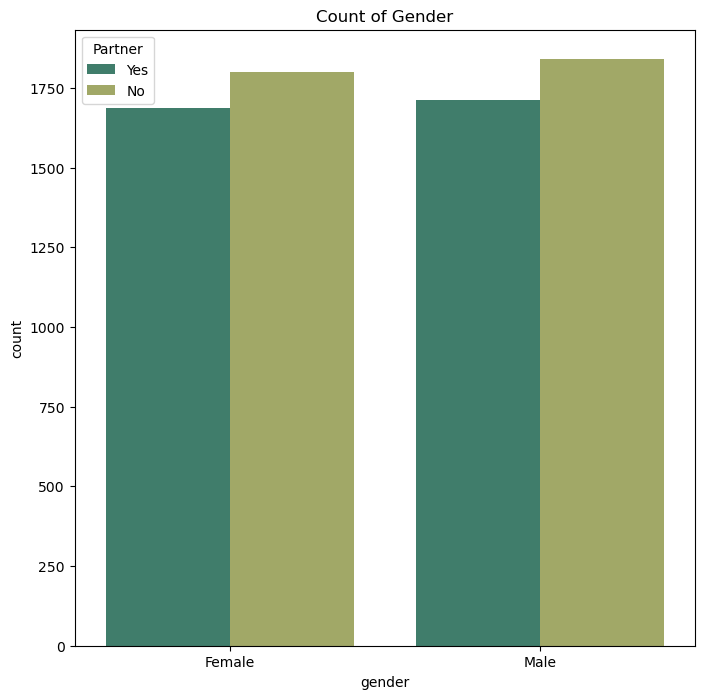

In [71]:
# investigating the Gender Method factor by Partner
plt.figure(figsize = (8,8))
sns.countplot( x= "gender" , hue = 'Partner', data = categorical_df , palette = "gist_earth")
plt.title('Count of Gender');

The plot shows that both male and female customers are more likely to not have a partner. Thay are 50% - 60% divided

### Multivariate Analysis

Analysis of more than one variable. 

In [74]:
# putting up all services into one dataframe for categorical analysis.

services_df = df[['PhoneService',
                  'MultipleLines',
                  'InternetService',
                  'OnlineSecurity',
                  'OnlineBackup',
                  'DeviceProtection',
                  'TechSupport',
                  'StreamingTV',
                  'StreamingMovies']]
services_df.head(3)

,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,No,No phone service,DSL,No,Yes,No,No,No,No
1,Yes,No,DSL,Yes,No,Yes,No,No,No
2,Yes,No,DSL,Yes,Yes,No,No,No,No


In [75]:
 # descriptive analytics for the services offered
services_df.describe()

,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
count,7021,7021,7021,7021,7021,7021,7021,7021,7021
unique,2,3,3,3,3,3,3,3,3
top,Yes,No,Fiber optic,No,No,No,No,No,No
freq,6339,3368,3090,3490,3080,3087,3465,2802,2777


In [76]:
# Convert the service df columns to a list 
services_cols = services_df.columns.to_list()
services_cols

['PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies']

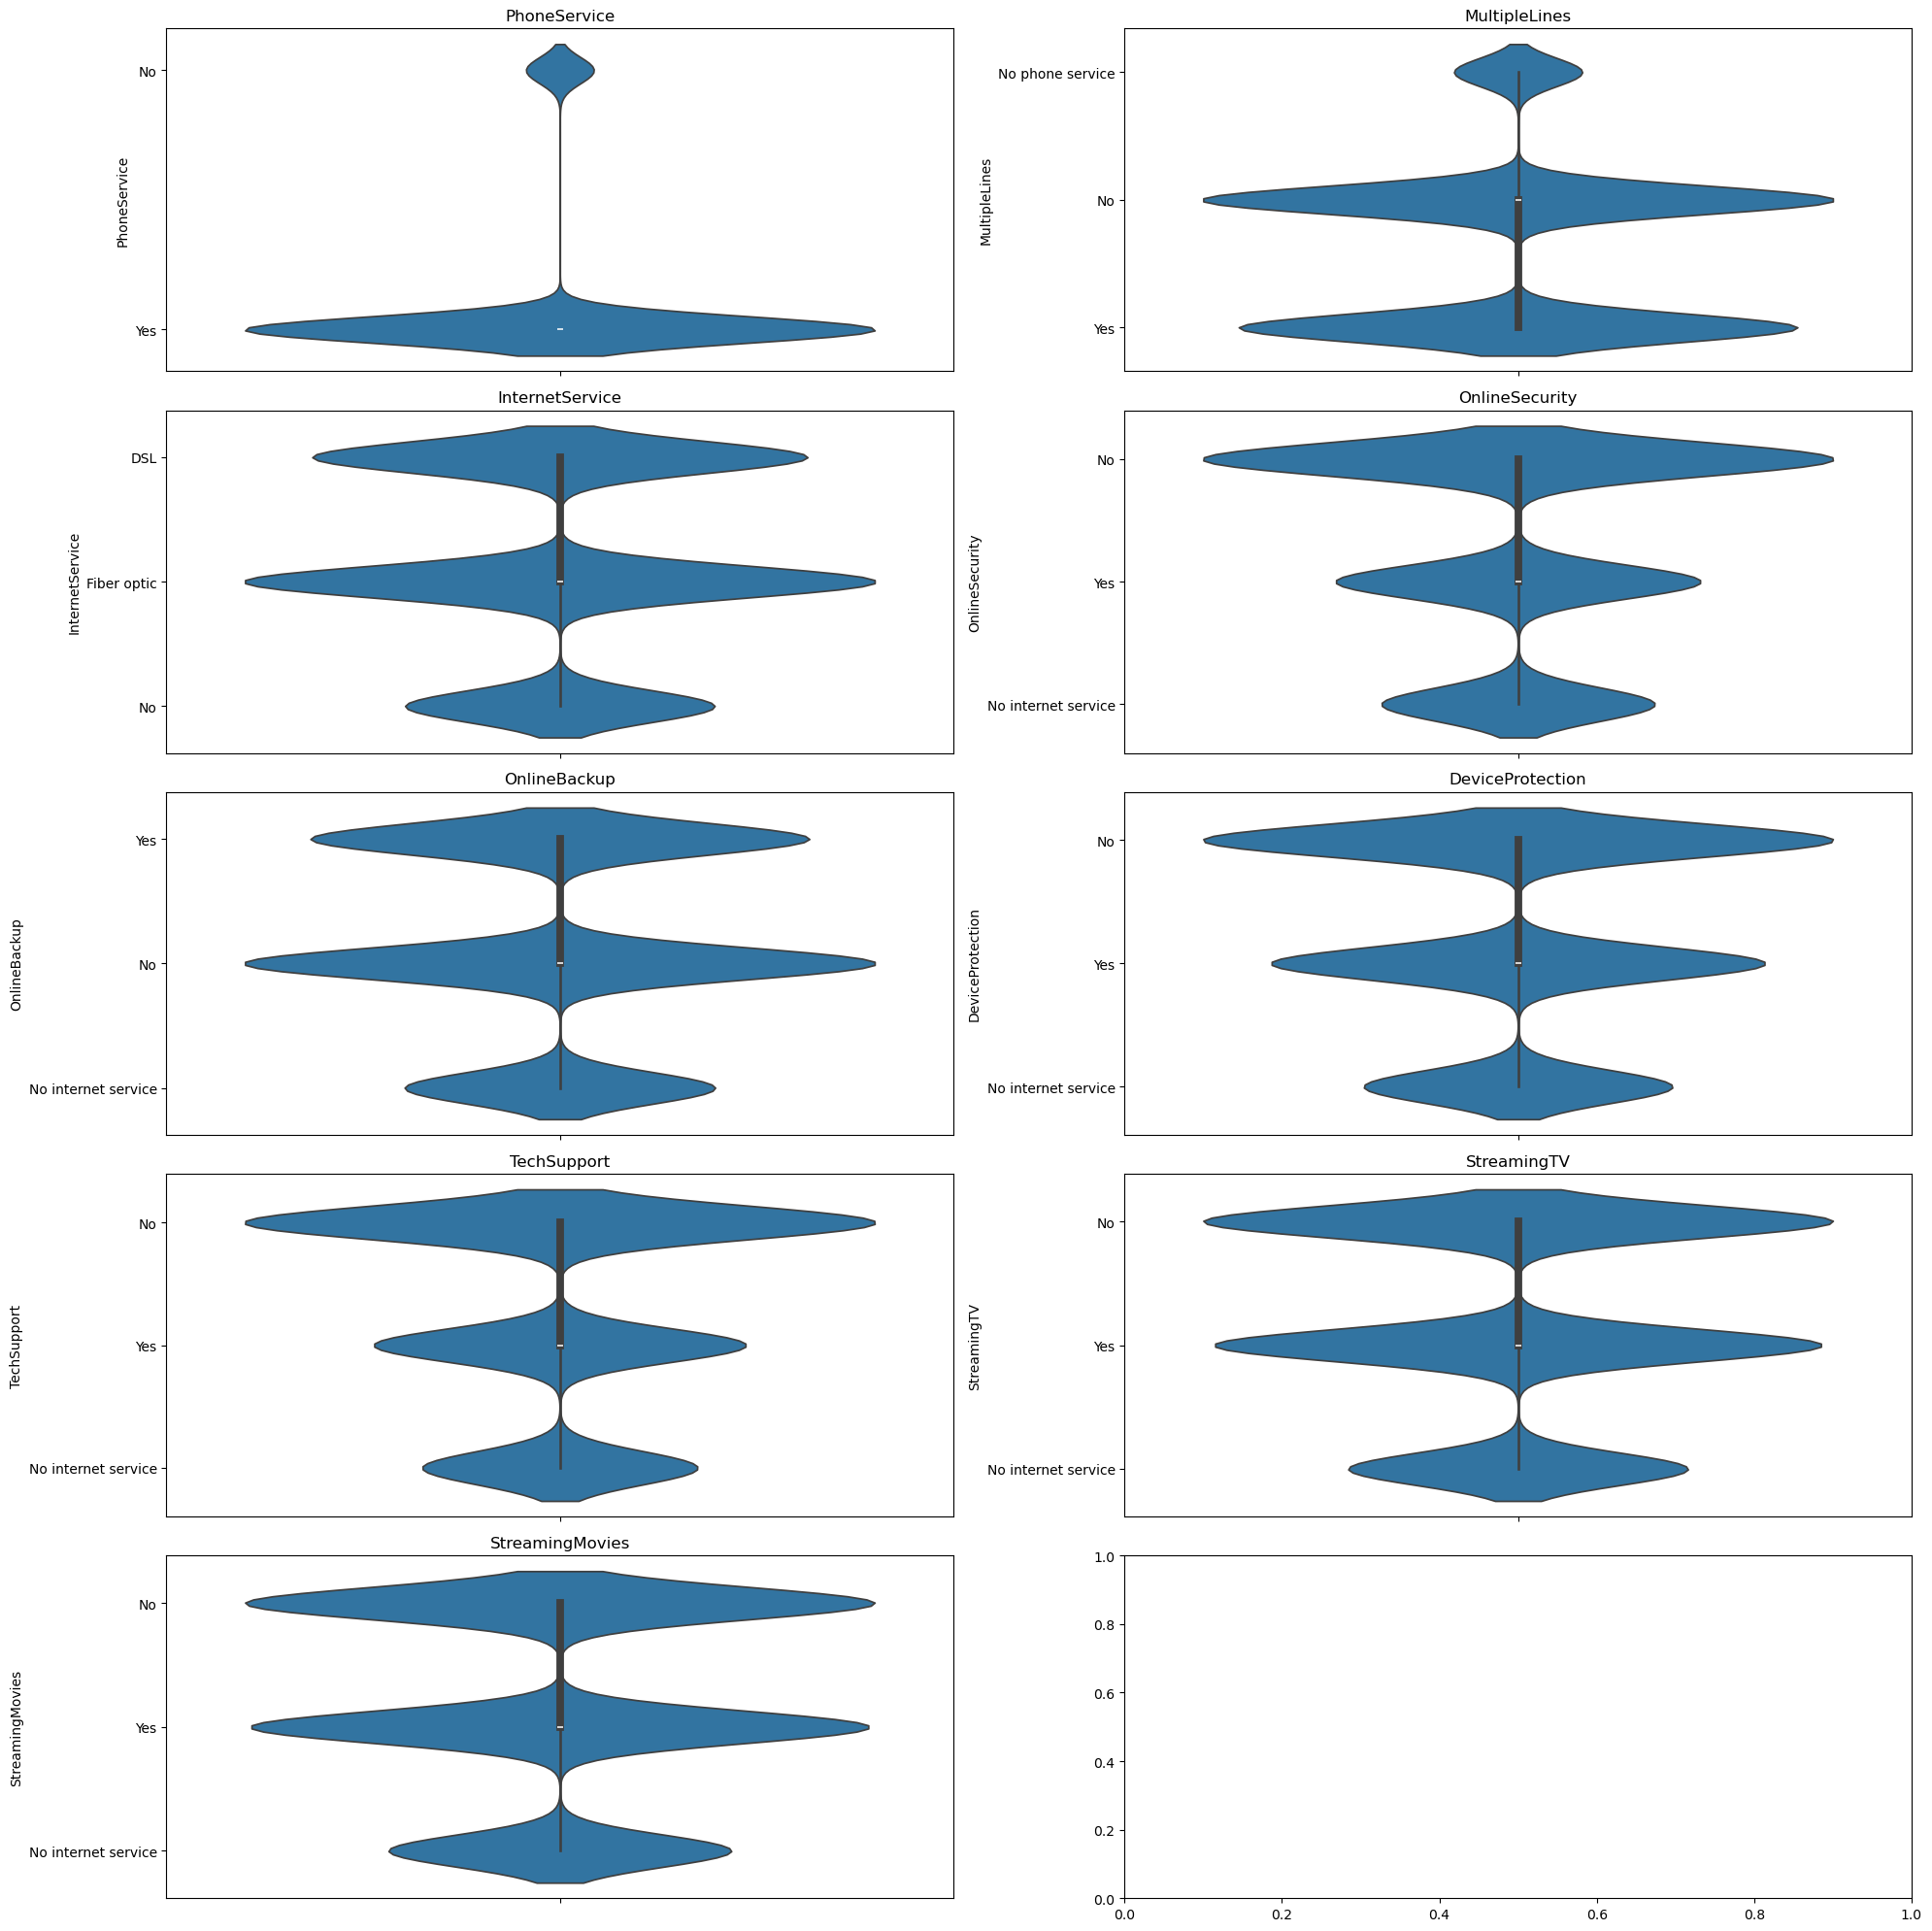

In [77]:
# Violinplot for the various services offered . 

fig, axes = plt.subplots ( nrows=5 , ncols= 2, figsize = (20,20))

position = axes.flatten()

for index, name_of_feature in enumerate (services_cols):
    sns.violinplot( data = services_df[name_of_feature] , ax = position[index])
    position[index].set_title(f'{name_of_feature}')

plt.tight_layout()
plt.show();

Recommendations 


Phone Service:
Focus on retaining customers with phone service by bundling it with other services, such as internet or streaming options.Focus on retaining customers with phone service by bundling it with other services, such as internet or streaming options.

Multiple Lines :
Offer promotions or discounts to encourage customers with a single line to add multiple lines, especially for families or businesses.

Internet Service :
Focus on converting DSL customers to fiber optic, which offers higher speeds and could increase satisfaction. Consider targeting customers without internet service with bundled internet and phone plans.

Online Security :
Promote the benefits of online security to existing internet customers, possibly offering it as an add-on service to reduce churn by increasing service stickiness.

Online Backup :
Bundle online backup services with other features such as online security or cloud storage, particularly for customers with higher service needs.

Device Protection :
Target customers with higher-value devices to promote device protection, emphasizing peace of mind and repair/replacement benefits.

Tech Support :
Offer tech support services as a value-added feature, especially to customers who frequently contact customer service or experience technical issues.

Streaming TV and Streaming Movies :
Bundle streaming services with internet plans to increase usage. Consider promotional offers, such as free months of streaming, to encourage customers to try the service and reduce churn.

    Summary:
    Cross-Sell and Upsell Opportunities: For underutilized services like online security, online backup, tech support, and streaming services, focus on cross-selling and upselling to existing customers. Bundling these services can increase customer satisfaction and reduce churn.


### Categorical Multivariate Analysis

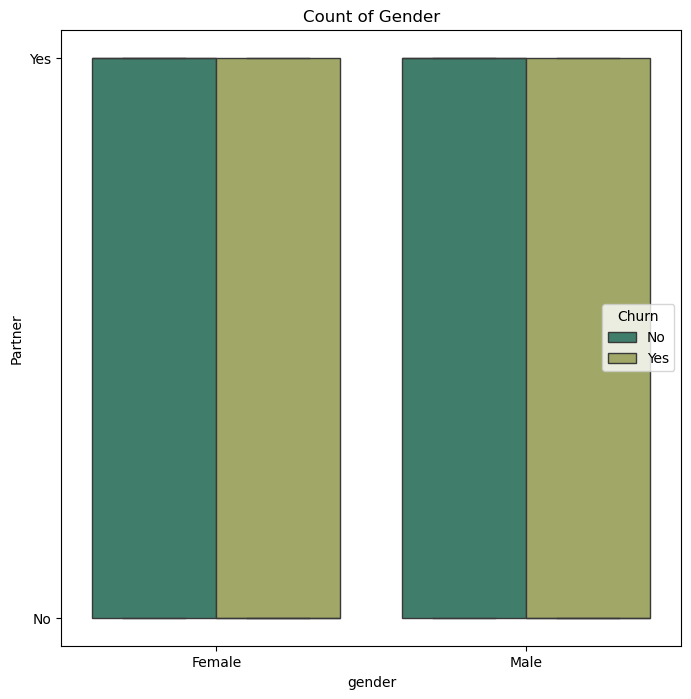

In [80]:
# investigating the Gender factor by patner and churn
plt.figure(figsize = (8,8))
sns.boxplot( x= "gender" , y = 'Partner', hue= 'Churn', data = df , palette = "gist_earth")
plt.title('Count of Gender');

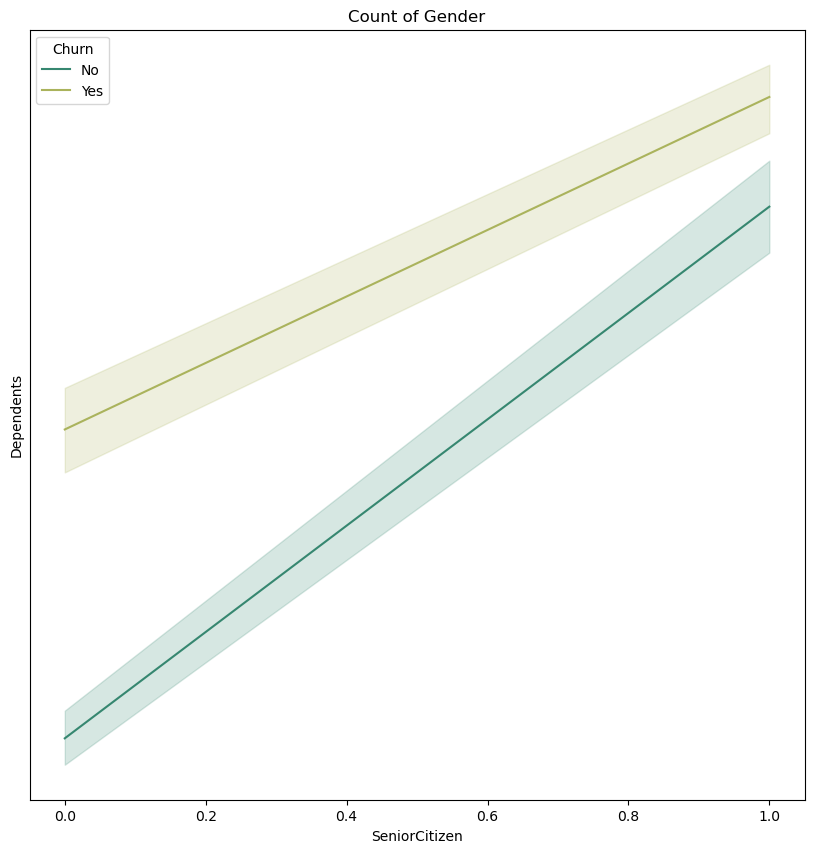

In [81]:
# investigating the Gender factor by Dependents and churn
plt.figure(figsize = (10,10))
sns.lineplot( x= "SeniorCitizen" , y = 'Dependents', hue= 'Churn', data = df , palette = "gist_earth")
plt.title('Count of Gender');

Both senior citizens and non-senior citizens with dependents appear less likely to churn than their counterparts without dependents. However, senior citizens with no dependents are slightly more likely to churn.The trend suggests that having dependents might provide some level of stability or reduce the likelihood of churn, regardless of senior citizen status.

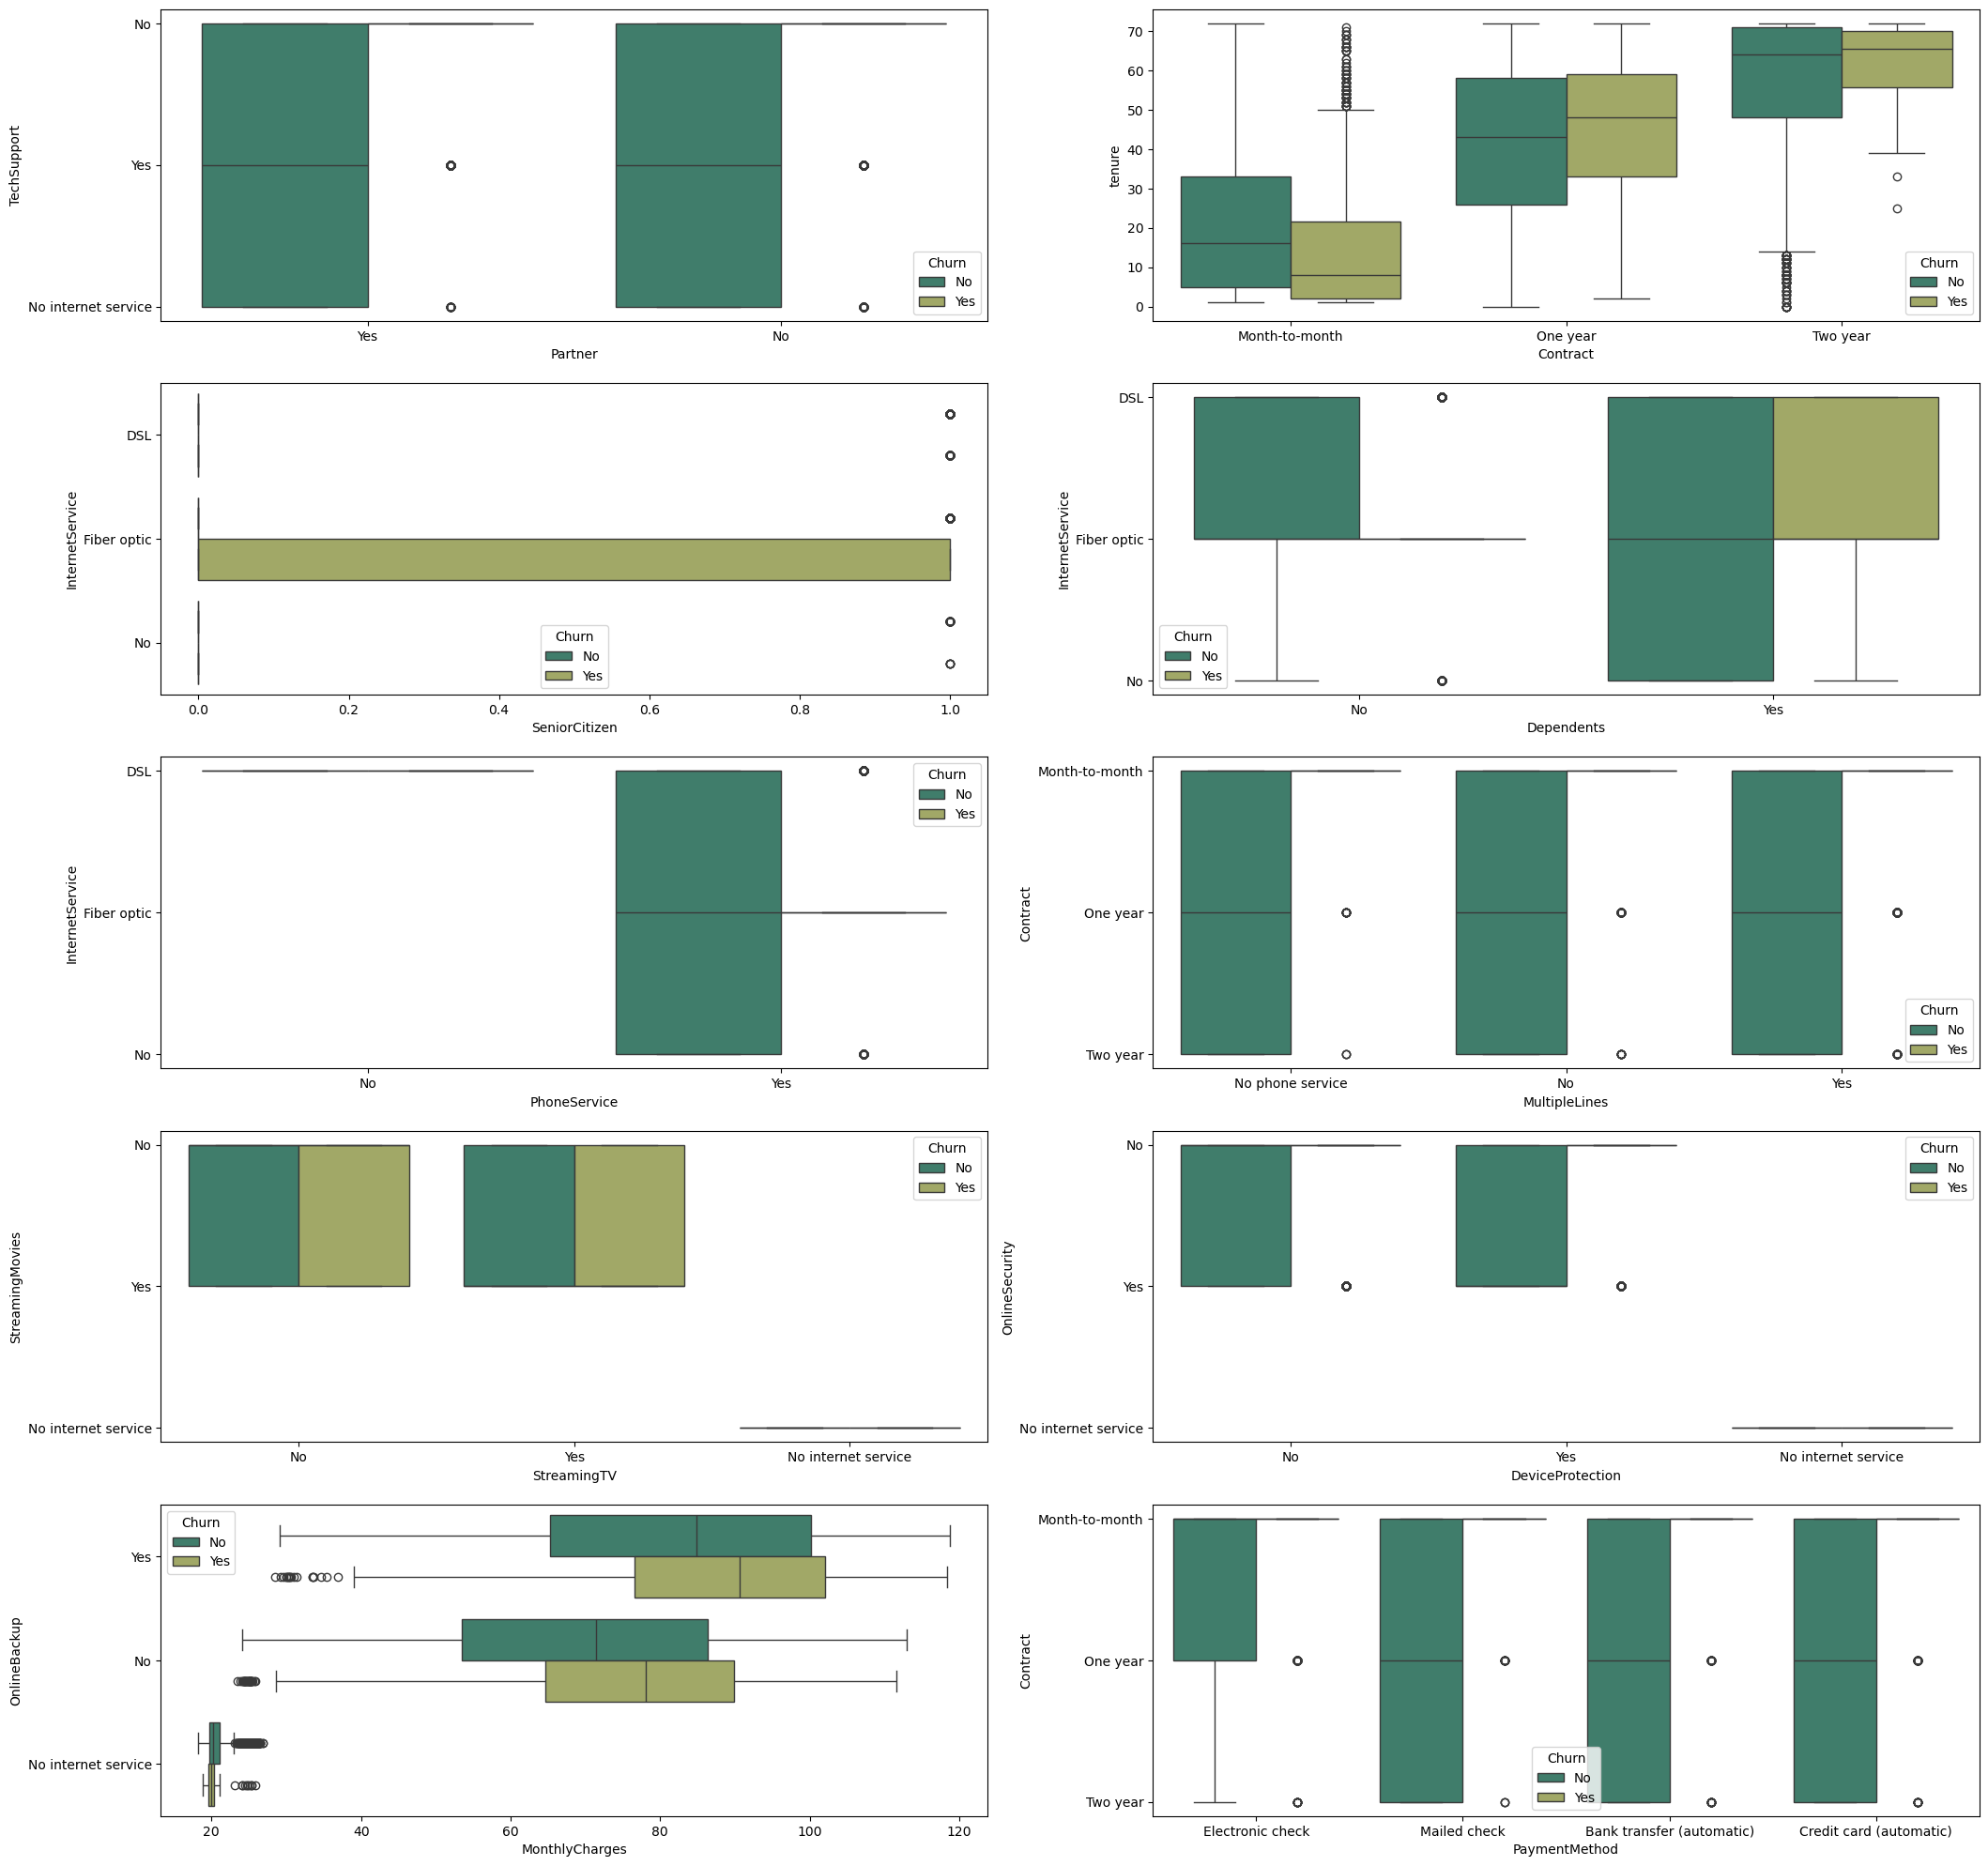

In [83]:
# Multivariate visualisations
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(25, 25)) 

# Barplot visualisation for the diffrent variables and Churn
sns.boxplot(x="Partner", y='TechSupport', data=df, hue='Churn', palette="gist_earth", ax=axes[0,0])
sns.boxplot(x="Contract", y='tenure', hue='Churn', data=df, palette="gist_earth", ax=axes[0,1])
sns.boxplot(x="SeniorCitizen", y='InternetService', hue='Churn', data=df, palette="gist_earth", ax=axes[1,0])
sns.boxplot(x="Dependents", y='InternetService', hue='Churn', data=df, palette="gist_earth", ax=axes[1,1])
sns.boxplot(x="PhoneService", y='InternetService', hue='Churn', data=df, palette="gist_earth", ax=axes[2,0])
sns.boxplot(x="MultipleLines", y='Contract', hue='Churn', data=df, palette="gist_earth", ax=axes[2,1])
sns.boxplot(x="StreamingTV", y='StreamingMovies', hue='Churn', data=df, palette="gist_earth", ax=axes[3,0])
sns.boxplot(x="DeviceProtection", y='OnlineSecurity', hue='Churn', data=df, palette="gist_earth", ax=axes[3,1])
sns.boxplot(x="MonthlyCharges", y='OnlineBackup', hue='Churn', data=df, palette="gist_earth", ax=axes[4,0])
sns.boxplot(x="PaymentMethod", y='Contract', hue='Churn', data=df, palette="gist_earth", ax=axes[4,1])
plt.show() 

Month-to-Month Contracts: We've observed that customers on month-to-month contracts have the highest churn rates across multiple variables. To reduce churn, converting these customers to longer-term contracts should be a key focus, potentially through targeted retention offers or incentives for switching to one- or two-year contracts.

Lack of Bundled Services: Customers who only subscribe to a single service, such as phone or internet, are more likely to churn. Offering bundled packages that include multiple lines or additional services, such as both internet and phone, could significantly reduce churn and increase customer stickiness.

Senior Citizens: Senior citizens, particularly those using fiber optic services, tend to churn at a higher rate. Simplifying service options and offering more affordable or tailored packages for this group could improve retention and reduce churn in this demographic.

Higher Monthly Charges: Customers with higher monthly bills, especially those who don't have additional services like device protection or online backup, are more likely to leave. Implementing tiered pricing plans, offering loyalty discounts, or promoting these added services can help retain high-paying customers and reduce churn.

# Modelling 

In [86]:
# Columns in the main dataframe 
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [87]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [88]:
# features separation for training  : Exclude churn for testing

features = df.drop(['Churn'], axis= 1)

In [89]:
# new feature columns
features.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50


### Categorical encoding of features

In [91]:
# Using Label encoder to encode .
# drop churn in encoding catergorical variables
# Dropping churn from Categorical DF for encoding .
newcat_df = categorical_df.drop(['Churn'], axis=1 )

In [92]:
# Import the label encoder for encoding
# Initialise the encoder
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [93]:
for column_name in newcat_df:
    features[column_name] = encoder.fit_transform(features[column_name])

In [94]:
# Confiming the info of our features
features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   int32  
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   int32  
 3   Dependents        7021 non-null   int32  
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   int32  
 6   MultipleLines     7021 non-null   int32  
 7   InternetService   7021 non-null   int32  
 8   OnlineSecurity    7021 non-null   int32  
 9   OnlineBackup      7021 non-null   int32  
 10  DeviceProtection  7021 non-null   int32  
 11  TechSupport       7021 non-null   int32  
 12  StreamingTV       7021 non-null   int32  
 13  StreamingMovies   7021 non-null   int32  
 14  Contract          7021 non-null   int32  
 15  PaperlessBilling  7021 non-null   int32  
 16  PaymentMethod     7021 non-null   int32  
 17  

In [95]:
# encode churn separately to avoid overfitting
df['Churn'] = encoder.fit_transform(df['Churn'])

In [96]:
# Labels for testing 
labels= df['Churn']

In [97]:
labels.info

<bound method Series.info of 0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7021, dtype: int32>

### Data Splitting

In [99]:
# Data Preprocessing
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler

In [100]:
len(features)

7021

In [101]:
len(labels)

7021

In [102]:
len(features) == len(labels)

True

In [103]:
labels.dtype

dtype('int32')

### logistic Regression

In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , confusion_matrix

# Separate training and testing features and labels .

Xtrain, Xtest, ytrain, ytest = train_test_split(features, labels, test_size= 0.2, random_state=42)

Xtrain.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3276,0,0,0,0,4,1,0,1,0,0,0,0,0,2,0,1,2,79.15,317.25
6266,1,1,0,0,33,1,2,1,0,2,2,0,0,0,0,1,1,83.85,2716.30


In [106]:
len(Xtrain) + len(Xtest) == len(features)

True

              precision    recall  f1-score   support

           0    0.84364   0.88129   0.86205      1053
           1    0.59016   0.51136   0.54795       352

    accuracy                        0.78861      1405
   macro avg    0.71690   0.69633   0.70500      1405
weighted avg    0.78013   0.78861   0.78336      1405



C:\Users\Ndumbi Kimani\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


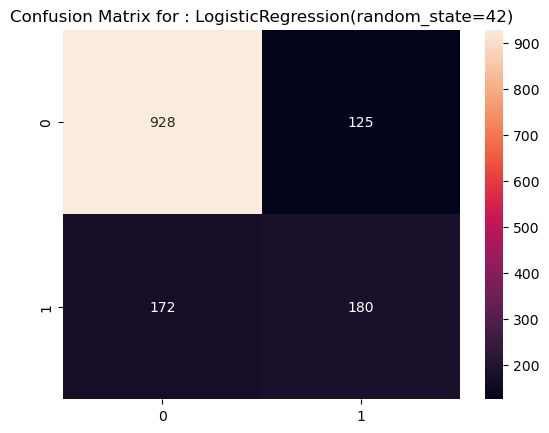

In [276]:
# logisticRegression 1

# Model initializations
model = LogisticRegression(random_state = 42)
model.fit(Xtrain, ytrain)

#predictions
predictions = model.predict(Xtest)

#visualisations
report = classification_report( ytest, predictions , digits=5) 
matrix = confusion_matrix( ytest, predictions)

print(report)
sns.heatmap( matrix, annot=True, fmt='g')
plt.title(f'Confusion Matrix for : {model}')
plt.show();

The model shows good performance with an accuracy of 82%, which is decent for churn prediction.
Precision (59%) indicates the model is moderately confident when it predicts a customer will churn, although this could be improved.
Recall (51%) shows that the model captures only about half of the actual churn cases, meaning it can be improved to catch more potential churners.

### Scale the Data

In [109]:
# Scaling the data

from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [110]:
#initialize the scaler
scaler = StandardScaler()

In [111]:
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)

              precision    recall  f1-score   support

           0    0.84895   0.88604   0.86710      1053
           1    0.60784   0.52841   0.56535       352

    accuracy                        0.79644      1405
   macro avg    0.72840   0.70722   0.71622      1405
weighted avg    0.78855   0.79644   0.79150      1405



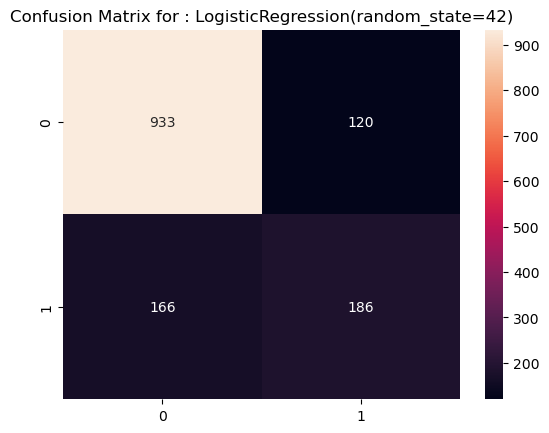

In [112]:
#Model Initializations
model = LogisticRegression(random_state =42)
model.fit (Xtrain_scaled, ytrain)
#predictions
predictions = model.predict( Xtest_scaled )

#visualisations
report = classification_report( ytest, predictions , digits=5 )
matrix = confusion_matrix ( ytest, predictions )

print(report)
sns.heatmap( matrix, annot=True, fmt='g')
plt.title(f'Confusion Matrix for : {model}')
plt.show();

#### Adding weight to see if the model would perfom better

              precision    recall  f1-score   support

           0    0.94201   0.63248   0.75682      1053
           1    0.44556   0.88352   0.59238       352

    accuracy                        0.69537      1405
   macro avg    0.69378   0.75800   0.67460      1405
weighted avg    0.81763   0.69537   0.71562      1405



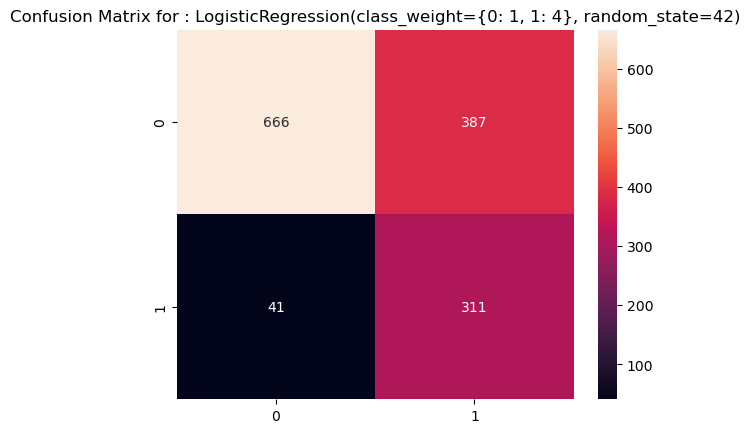

In [114]:
#Model Initializations
model = LogisticRegression(random_state =42, class_weight = {0:1 , 1:4})
model.fit (Xtrain_scaled, ytrain)
#predictions
predictions = model.predict( Xtest_scaled )

#visualisations
report = classification_report( ytest, predictions , digits=5 )
matrix = confusion_matrix ( ytest, predictions )

print(report)
sns.heatmap( matrix, annot=True, fmt='g');

plt.title(f'Confusion Matrix for : {model}')
plt.show();

Testing class weight: {0: 1, 1: 2}
              precision    recall  f1-score   support

           0    0.89625   0.77113   0.82899      1053
           1    0.51703   0.73295   0.60635       352

    accuracy                        0.76157      1405
   macro avg    0.70664   0.75204   0.71767      1405
weighted avg    0.80124   0.76157   0.77321      1405



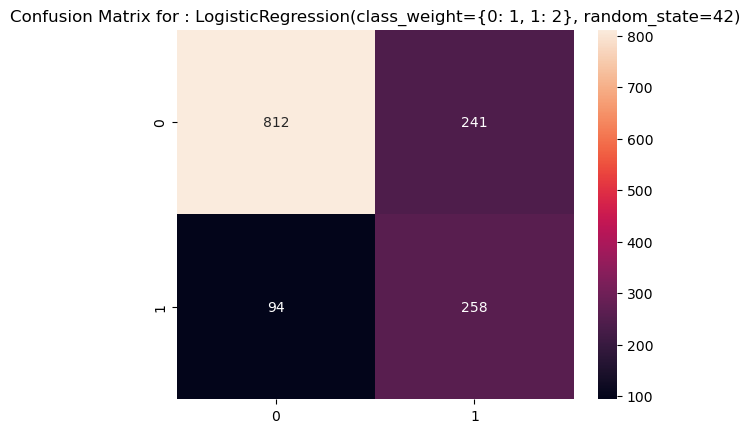

Testing class weight: {0: 1, 1: 3}
              precision    recall  f1-score   support

           0    0.92065   0.69421   0.79155      1053
           1    0.47300   0.82102   0.60021       352

    accuracy                        0.72598      1405
   macro avg    0.69683   0.75761   0.69588      1405
weighted avg    0.80850   0.72598   0.74362      1405



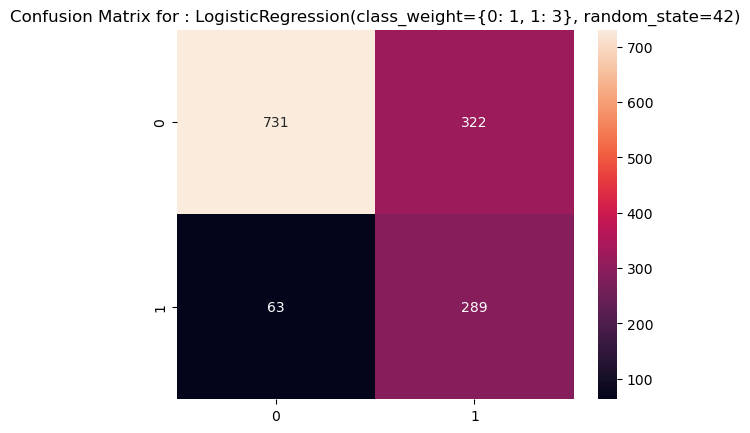

Testing class weight: {0: 1, 1: 4}
              precision    recall  f1-score   support

           0    0.94201   0.63248   0.75682      1053
           1    0.44556   0.88352   0.59238       352

    accuracy                        0.69537      1405
   macro avg    0.69378   0.75800   0.67460      1405
weighted avg    0.81763   0.69537   0.71562      1405



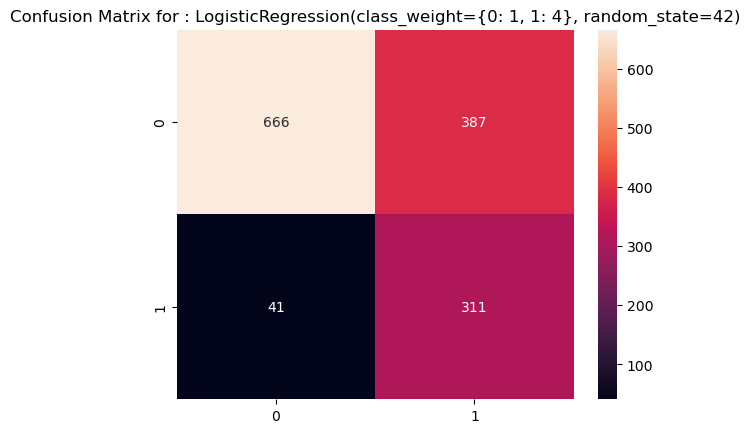

Testing class weight: {0: 1, 1: 5}
              precision    recall  f1-score   support

           0    0.95931   0.58215   0.72459      1053
           1    0.42559   0.92614   0.58318       352

    accuracy                        0.66833      1405
   macro avg    0.69245   0.75414   0.65389      1405
weighted avg    0.82560   0.66833   0.68916      1405



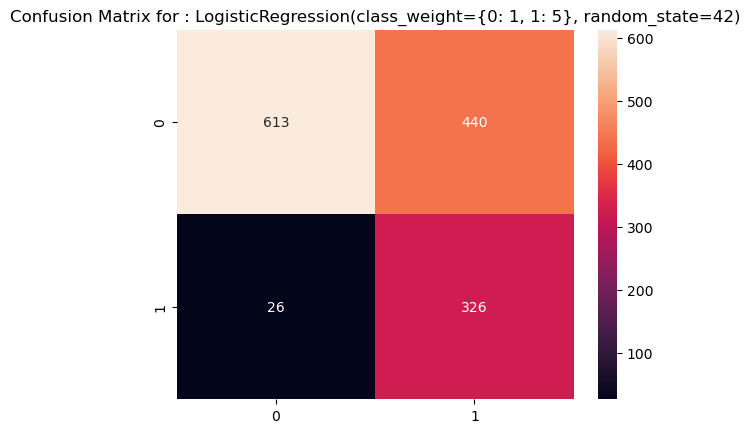

In [115]:
#Class weights

weights = [{0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 4}, {0: 1, 1: 5}]

# Loop over each class weight
for weight in weights:
    print(f"Testing class weight: {weight}")

    model = LogisticRegression(random_state =42, class_weight = weight)
    model.fit (Xtrain_scaled, ytrain)
    #predictions
    predictions = model.predict( Xtest_scaled )
    
    #visualisations
    report = classification_report( ytest, predictions , digits=5 )
    matrix = confusion_matrix ( ytest, predictions )
    
    print(report)
    sns.heatmap( matrix, annot=True, fmt='g');
    
    plt.title(f'Confusion Matrix for : {model}')
    plt.show();



**Effect of Class Weights**:
   - Class Weight {0:1, 1:2}: Reduces false negatives to 94, improving recall of churned customers.
   - Class Weight {0:1, 1:3}: Further reduces false negatives to 63 while correctly identifying 289 churned customers, though false positives rise to 322.
   - Class Weight {0:1, 1:4}: Maximizes correct churn identification (311), but false positives increase significantly (387).

In the results, tuning the class weights has proven to be an effective strategy for handling the imbalance in our churn prediction.

Optimal Balance: The best balance is achieved at a class weight of {0:1, 1:3}, where we see a more even trade-off between false positives and false negatives.

Trade-off: Increasing the weight on churned customers significantly improves recall, meaning we’re better at identifying those at risk of leaving. However, this comes with a slight drop in precision, which means we may misclassify some loyal customers as potential churners. This trade-off depends on what’s more important to the business.

For Connect Tel, if our primary goal is to ensure we capture as many churned customers as possible, even if it means mistakenly flagging some loyal customers, then using a higher class weight, such as 3 or 4, would be effective. However, if precision—minimizing false alarms—is also a priority, we need to fine-tune the model carefully to strike the right balance between recall and precision.

This decision will ultimately depend on the business's appetite for risk and the cost implications of targeting non-churners.


### Adding other classifiers to training and test

In [118]:
# Training using other models 
# Data Classifier libraries
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC , SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC


In [351]:
classifiers = [[ XGBClassifier(random_state = 42),'XGB Classifier'],
               [RandomForestClassifier(random_state = 42, class_weight = {0:1 , 1:3}),'Random Forest'],
               [KNeighborsClassifier(), 'K-nearest Neighbours'],
               [SGDClassifier(random_state = 42, class_weight = {0:1 , 1:3}), 'SGD Classifier'],
               [SVC(random_state = 42, class_weight = {0:1 , 1:3}), 'SVC'],
               [GaussianNB(), 'Naive Bayes'],
               [DecisionTreeClassifier(random_state = 42, class_weight = {0:1 , 1:3}), 'Decision tree'],
               [LogisticRegression(random_state = 42, class_weight = {0:1 , 1:3}), 'Logistic regression']
              ]

In [353]:
classifiers [2]

[KNeighborsClassifier(), 'K-nearest Neighbours']

 <===XGB Classifier===> 
              precision    recall  f1-score   support

           0    0.83211   0.86135   0.84648      1053
           1    0.53651   0.48011   0.50675       352

    accuracy                        0.76584      1405
   macro avg    0.68431   0.67073   0.67661      1405
weighted avg    0.75805   0.76584   0.76136      1405



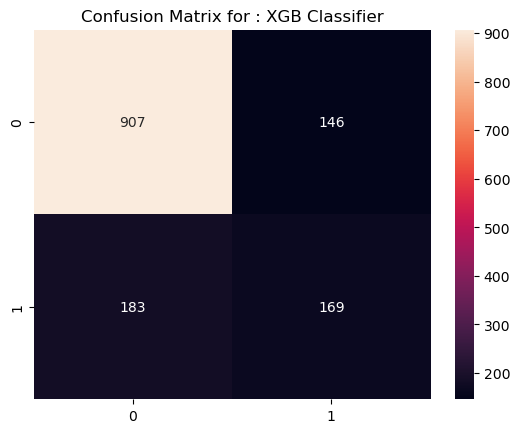

 <===Random Forest===> 
              precision    recall  f1-score   support

           0    0.82822   0.89744   0.86144      1053
           1    0.59091   0.44318   0.50649       352

    accuracy                        0.78363      1405
   macro avg    0.70956   0.67031   0.68397      1405
weighted avg    0.76877   0.78363   0.77251      1405



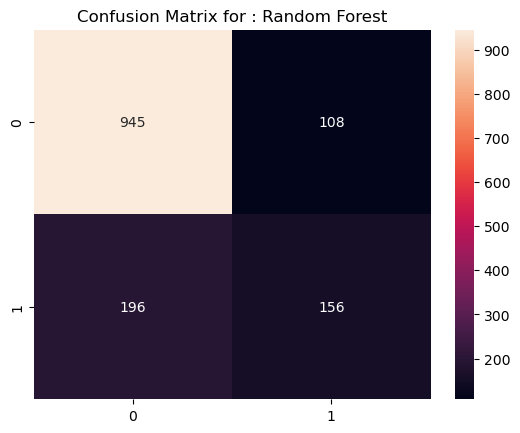

 <===K-nearest Neighbours===> 
              precision    recall  f1-score   support

           0    0.84110   0.83951   0.84030      1053
           1    0.52260   0.52557   0.52408       352

    accuracy                        0.76085      1405
   macro avg    0.68185   0.68254   0.68219      1405
weighted avg    0.76131   0.76085   0.76108      1405



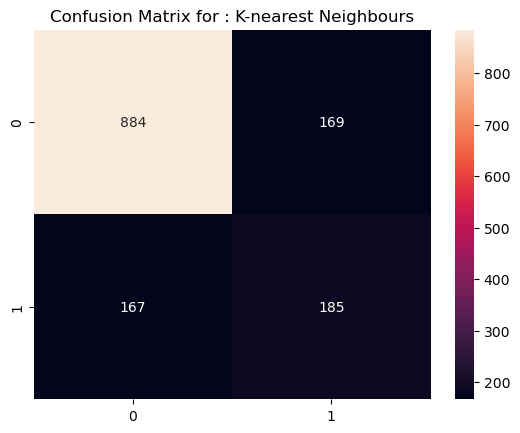

 <===SGD Classifier===> 
              precision    recall  f1-score   support

           0    0.94345   0.64957   0.76940      1053
           1    0.45735   0.88352   0.60271       352

    accuracy                        0.70819      1405
   macro avg    0.70040   0.76655   0.68606      1405
weighted avg    0.82166   0.70819   0.72764      1405



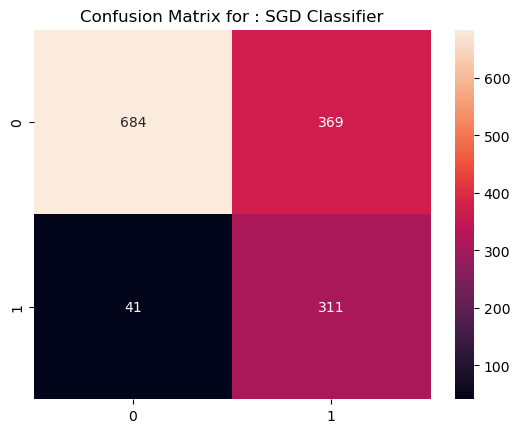

 <===SVC===> 
              precision    recall  f1-score   support

           0    0.89722   0.70465   0.78936      1053
           1    0.46194   0.75852   0.57419       352

    accuracy                        0.71815      1405
   macro avg    0.67958   0.73159   0.68178      1405
weighted avg    0.78817   0.71815   0.73545      1405



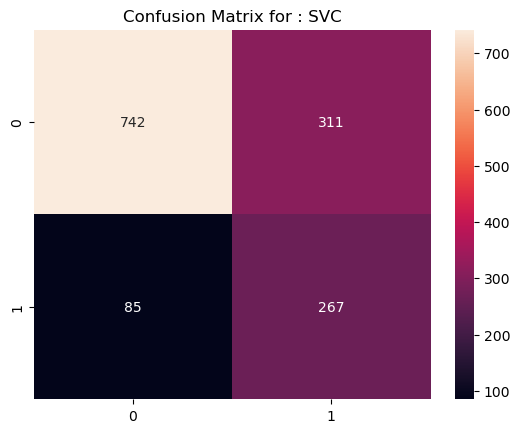

 <===Naive Bayes===> 
              precision    recall  f1-score   support

           0    0.90138   0.74644   0.81662      1053
           1    0.49906   0.75568   0.60113       352

    accuracy                        0.74875      1405
   macro avg    0.70022   0.75106   0.70888      1405
weighted avg    0.80058   0.74875   0.76263      1405



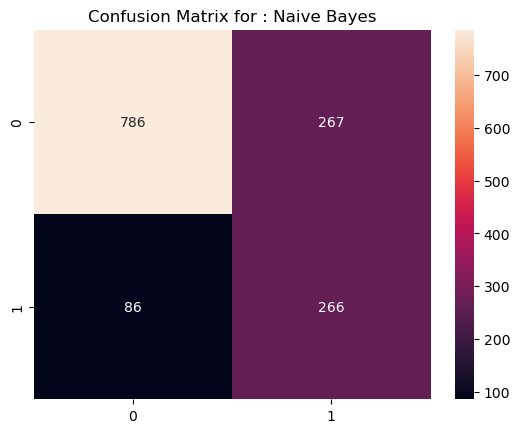

 <===Decision tree===> 
              precision    recall  f1-score   support

           0    0.82331   0.83191   0.82759      1053
           1    0.48094   0.46591   0.47330       352

    accuracy                        0.74021      1405
   macro avg    0.65212   0.64891   0.65045      1405
weighted avg    0.73753   0.74021   0.73883      1405



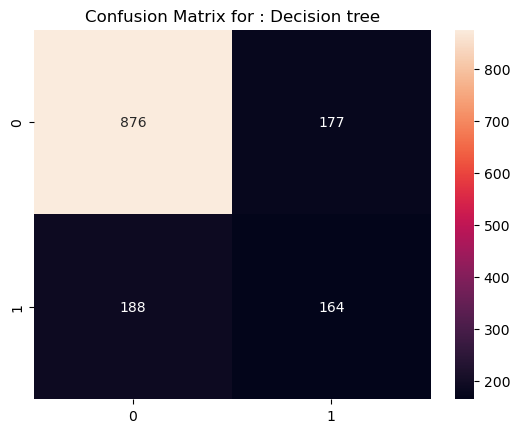

 <===Logistic regression===> 
              precision    recall  f1-score   support

           0    0.92065   0.69421   0.79155      1053
           1    0.47300   0.82102   0.60021       352

    accuracy                        0.72598      1405
   macro avg    0.69683   0.75761   0.69588      1405
weighted avg    0.80850   0.72598   0.74362      1405



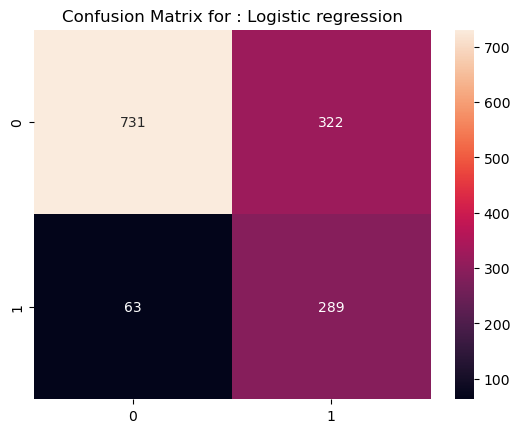

In [367]:
for classifier in classifiers:
    model = classifier [0]
    model_name = classifier[1]
    print(f" <==={model_name}===> ")
    # Training 
    model = model.fit(Xtrain_scaled, ytrain)
    # predictions
    predictions = model.predict(Xtest_scaled)
    report = classification_report (ytest, predictions, digits = 5)
    matrix = confusion_matrix(ytest, predictions)
    print(report)
    # Plot
    sns.heatmap(matrix, annot =True, fmt='g')
    plt.title(f'Confusion Matrix for : {model_name}')
    plt.show();

Best Performing Modes are XGBoost and Logistic Regression (with tuned class weights) seem to balance both precision and recall very well. 

#### Feature importances and feature selection 

Do we need all the features?

In [123]:
Xtrain.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3276,0,0,0,0,4,1,0,1,0,0,0,0,0,2,0,1,2,79.15,317.25
6266,1,1,0,0,33,1,2,1,0,2,2,0,0,0,0,1,1,83.85,2716.30
1324,0,0,1,1,4,1,0,2,1,1,1,1,1,1,0,0,3,20.35,76.35
5201,1,0,0,0,9,1,0,2,1,1,1,1,1,1,1,1,2,19.90,164.60
4080,0,0,1,1,29,1,2,2,1,1,1,1,1,1,2,0,3,26.10,692.55


In [286]:
# Only decision tree and XGB classifiers have feature importance. 

classifiers[:]

[[XGBClassifier(base_score=None, booster=None, callbacks=None,
                class_weight={0: 1, 1: 3}, colsample_bylevel=None,
                colsample_bynode=None, colsample_bytree=None, device=None,
                early_stopping_rounds=None, enable_categorical=False,
                eval_metric=None, feature_types=None, gamma=None,
                grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=None, max_bin=None,
                max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=None, max_leaves=None,
                min_child_weight=None, missing=nan, monotone_constraints=None,
                multi_strategy=None, n_estimators=None, n_jobs=None,
                num_parallel_tree=None, ...),
  'XGB Classifier'],
 [RandomForestClassifier(class_weight={0: 1, 1: 3}, random_state=42),
  'Random Forest'],
 [KNeighborsClassifier(), 'K-nearest Neighbours'],
 [SGDClassifier(class_weight={0: 

In [125]:
classifiers[6][0]

DecisionTreeClassifier(class_weight={0: 1, 1: 3}, random_state=42)

In [126]:
classifiers[0][0]

XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight={0: 1, 1: 3}, colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [127]:
# Decision tree classifier : Feature importance
tree_importances = classifiers[6][0].feature_importances_

In [128]:
#XGB Classifier : Feature importance
xgb_importances = classifiers[0][0].feature_importances_

In [129]:
# Column head names.

feature_names = features.columns

In [130]:
tree_importances_df = pd.DataFrame( {'features': feature_names, 'Forest Importances': tree_importances}  )

#### Decision Tree Classifier Importances

In [132]:
# Arrange the columns in descending order.

tree_importances_df = tree_importances_df.sort_values( by = 'Forest Importances' , ascending = False)
tree_importances_df

,features,Forest Importances
14,Contract,0.233882
18,TotalCharges,0.197351
17,MonthlyCharges,0.184924
4,tenure,0.104509
8,OnlineSecurity,0.044285
16,PaymentMethod,0.036564
7,InternetService,0.024446
0,gender,0.024383
1,SeniorCitizen,0.020882
3,Dependents,0.019305


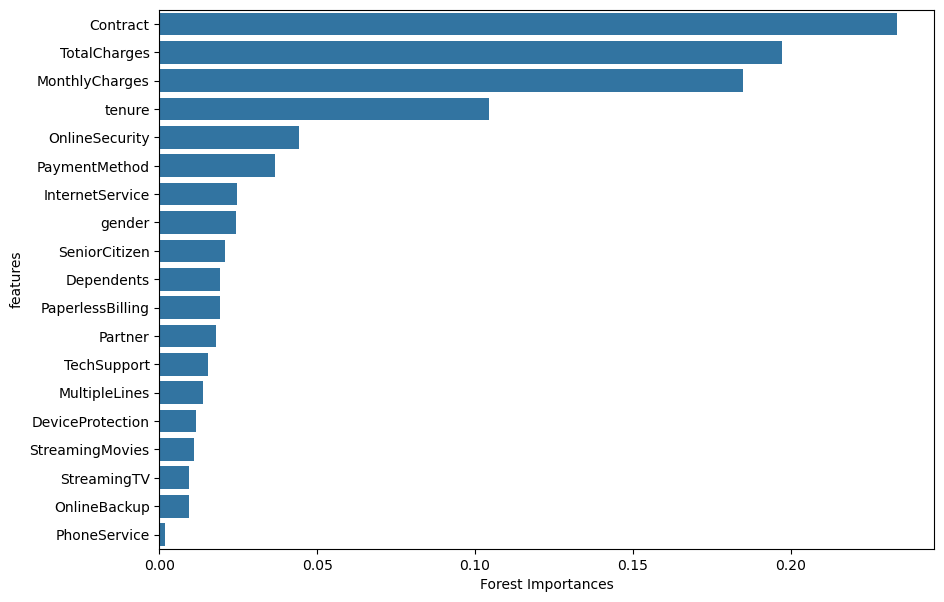

In [133]:
# Visualisation of the features by their feature importance in descending order
plt.figure(figsize =(10,7))
sns.barplot( x= "Forest Importances" , y = "features", data = tree_importances_df)

plt.show;

In [134]:
# select the top 5 Features 
top5_tree_features = tree_importances_df[:5]

top5_tree_features

,features,Forest Importances
14,Contract,0.233882
18,TotalCharges,0.197351
17,MonthlyCharges,0.184924
4,tenure,0.104509
8,OnlineSecurity,0.044285


In [135]:
# convert the feature importances into training and testing data

Xtrain_top5_tree = Xtrain[top5_tree_features['features'].values]
Xtest_top5_tree = Xtest[top5_tree_features['features'].values]

In [136]:
# scale the data

scaler = StandardScaler()

Xtrain_top5_scaled_tree = scaler.fit_transform(Xtrain_top5_tree) 
Xtest_top5_scaled_tree = scaler.transform(Xtest_top5_tree)

In [137]:
# confirming the output
Xtrain_top5_scaled_tree

array([[-0.82737914, -0.87070346,  0.47484852, -1.16251889, -0.91393356],
       [-0.82737914,  0.18962554,  0.63066732,  0.02631487, -0.91393356],
       [-0.82737914, -0.97717612, -1.47454416, -1.16251889,  0.25046092],
       ...,
       [-0.82737914, -0.38910137, -0.33408313, -0.260645  , -0.91393356],
       [ 1.58453949, -0.7286957 , -1.47122886, -0.05567366,  0.25046092],
       [ 0.37858018, -0.80880434, -1.49277827, -0.260645  ,  0.25046092]])

 <===XGB Classifier===> 
              precision    recall  f1-score   support

           0    0.83034   0.87844   0.85371      1053
           1    0.56014   0.46307   0.50700       352

    accuracy                        0.77438      1405
   macro avg    0.69524   0.67076   0.68036      1405
weighted avg    0.76265   0.77438   0.76685      1405



C:\Users\Ndumbi Kimani\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:34:45] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)


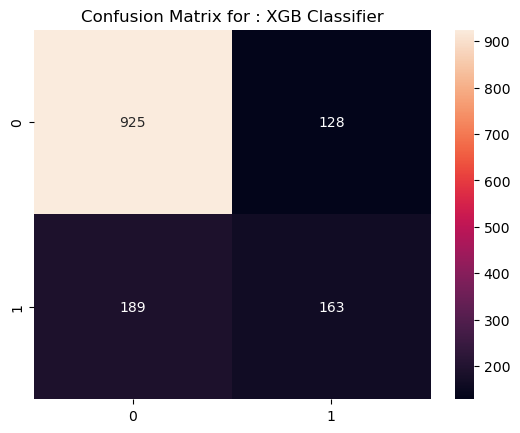

 <===Random Forest===> 
              precision    recall  f1-score   support

           0    0.83625   0.86325   0.84953      1053
           1    0.54717   0.49432   0.51940       352

    accuracy                        0.77082      1405
   macro avg    0.69171   0.67878   0.68447      1405
weighted avg    0.76382   0.77082   0.76682      1405



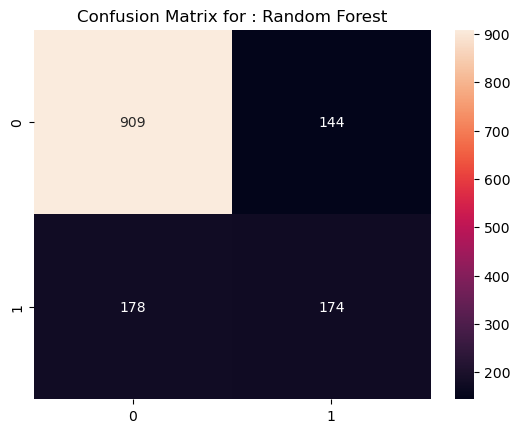

 <===K-nearest Neighbours===> 
              precision    recall  f1-score   support

           0    0.83548   0.86325   0.84914      1053
           1    0.54574   0.49148   0.51719       352

    accuracy                        0.77011      1405
   macro avg    0.69061   0.67736   0.68316      1405
weighted avg    0.76289   0.77011   0.76597      1405



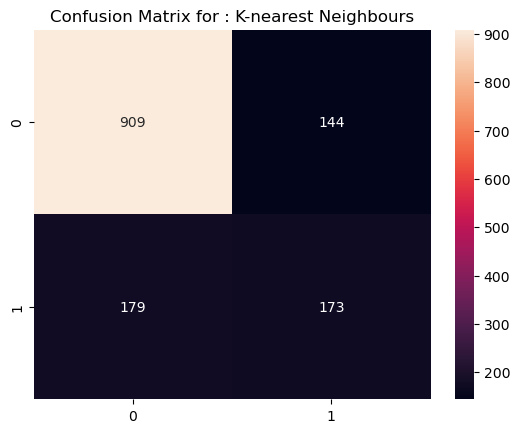

 <===SGD Classifier===> 
              precision    recall  f1-score   support

           0    0.95147   0.61443   0.74668      1053
           1    0.44000   0.90625   0.59239       352

    accuracy                        0.68754      1405
   macro avg    0.69574   0.76034   0.66953      1405
weighted avg    0.82333   0.68754   0.70803      1405



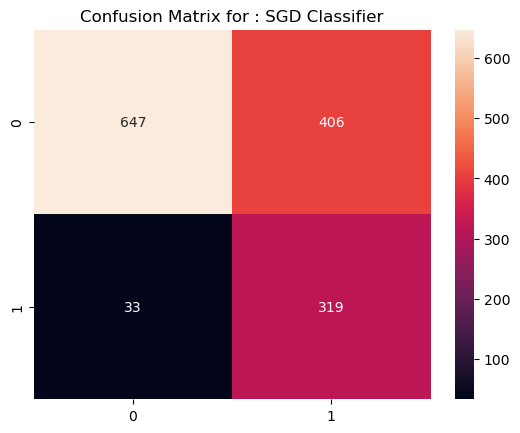

 <===SVC===> 
              precision    recall  f1-score   support

           0    0.92162   0.69231   0.79067      1053
           1    0.47231   0.82386   0.60041       352

    accuracy                        0.72527      1405
   macro avg    0.69697   0.75809   0.69554      1405
weighted avg    0.80905   0.72527   0.74301      1405



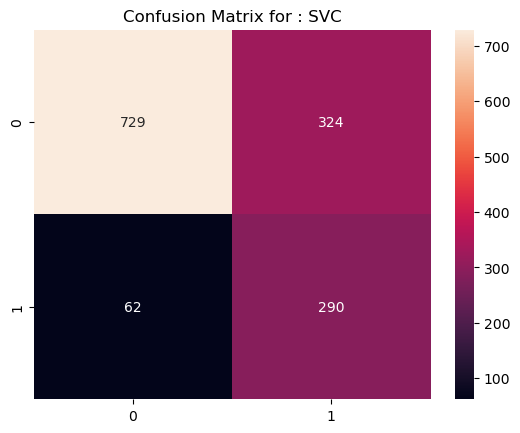

 <===Naive Bayes===> 
              precision    recall  f1-score   support

           0    0.89534   0.74739   0.81470      1053
           1    0.49430   0.73864   0.59226       352

    accuracy                        0.74520      1405
   macro avg    0.69482   0.74301   0.70348      1405
weighted avg    0.79486   0.74520   0.75897      1405



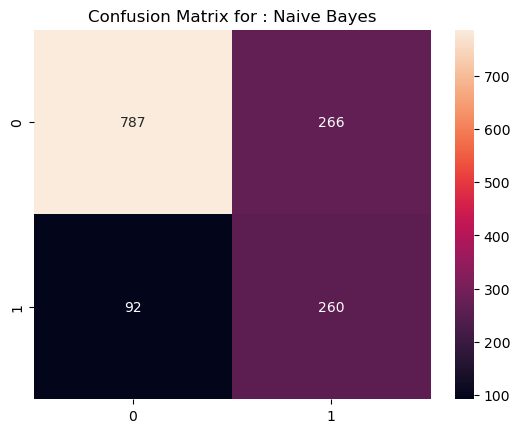

 <===Decision tree===> 
              precision    recall  f1-score   support

           0    0.83656   0.82146   0.82894      1053
           1    0.49326   0.51989   0.50622       352

    accuracy                        0.74591      1405
   macro avg    0.66491   0.67067   0.66758      1405
weighted avg    0.75055   0.74591   0.74809      1405



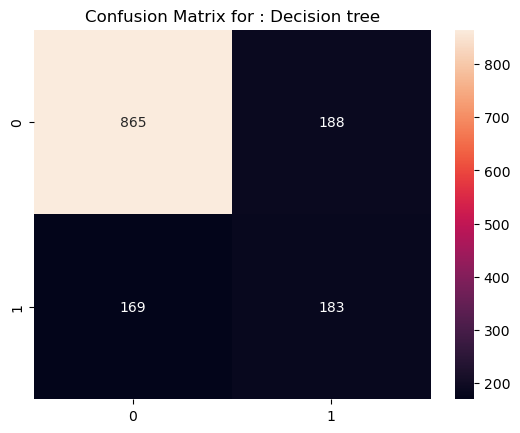

 <===Logistic regression===> 
              precision    recall  f1-score   support

           0    0.92199   0.68471   0.78583      1053
           1    0.46709   0.82670   0.59692       352

    accuracy                        0.72028      1405
   macro avg    0.69454   0.75571   0.69138      1405
weighted avg    0.80803   0.72028   0.73850      1405



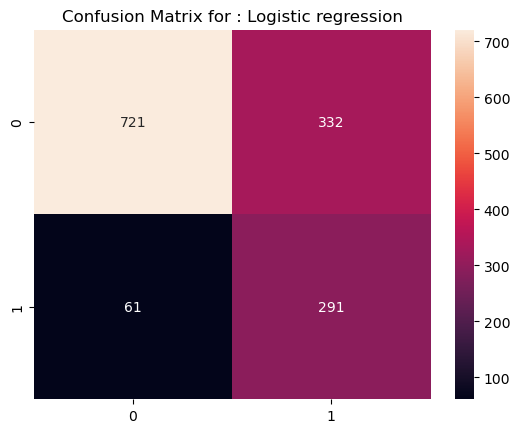

In [138]:
# Model Training the Top 5 important features in Deceision Tree, through all the 8 classifiers

for classifier in classifiers:
    model = classifier [0]
    model_name = classifier[1]
    print(f" <==={model_name}===> ")
    # Training 
    model = model.fit(Xtrain_top5_scaled_tree, ytrain)
    # predictions
    predictions = model.predict(Xtest_top5_scaled_tree)
    report = classification_report (ytest, predictions, digits =5, zero_division = 0 )
    matrix = confusion_matrix(ytest, predictions)
    print(report)
    # Plot
    sns.heatmap(matrix, annot =True, fmt='g')
    plt.title(f'Confusion Matrix for : {model_name}')
    plt.show();

#### XGB Feature Importances 

In [140]:
# XGB feature importances
xgb_importances_df = pd.DataFrame( {'features': feature_names, 'Forest Importances': xgb_importances}  )

In [141]:
# Arrange the columns in descending order.
xgb_importances_df = xgb_importances_df.sort_values( by = 'Forest Importances' , ascending = False)
xgb_importances_df

,features,Forest Importances
14,Contract,0.331588
7,InternetService,0.157133
8,OnlineSecurity,0.088979
11,TechSupport,0.070318
5,PhoneService,0.034435
4,tenure,0.031388
13,StreamingMovies,0.029116
9,OnlineBackup,0.027785
1,SeniorCitizen,0.024405
12,StreamingTV,0.023633


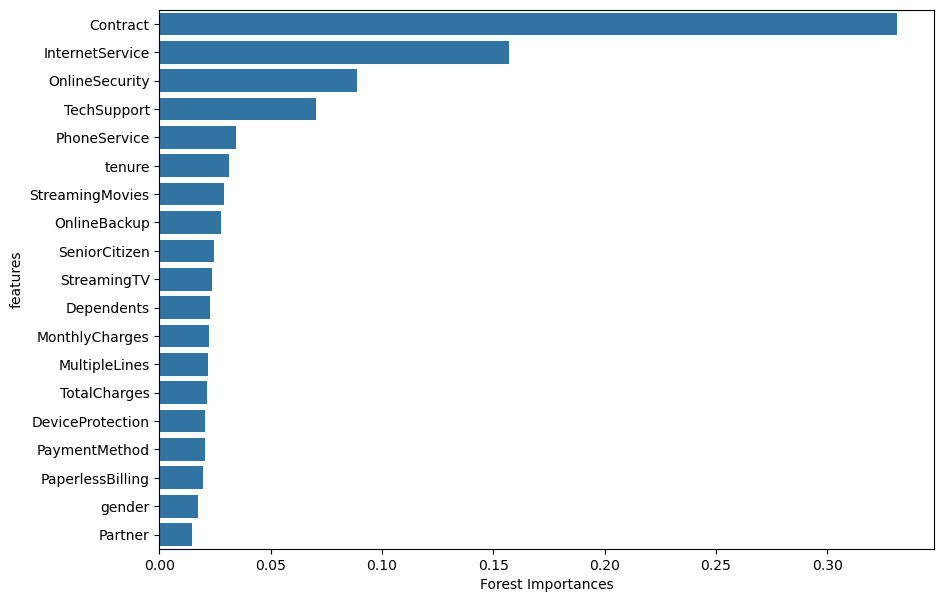

In [142]:
# Bar plot visualisation of the feature columns in descending order based on the most important feature

plt.figure(figsize =(10,7))
sns.barplot( x= "Forest Importances" , y = "features", data = xgb_importances_df)

plt.show;

In [143]:
# Select the top 5 features
top5_xgb_features = xgb_importances_df[:5]
top5_xgb_features

,features,Forest Importances
14,Contract,0.331588
7,InternetService,0.157133
8,OnlineSecurity,0.088979
11,TechSupport,0.070318
5,PhoneService,0.034435


In [144]:
top5_xgb_features['features'].values

array(['Contract', 'InternetService', 'OnlineSecurity', 'TechSupport',
       'PhoneService'], dtype=object)

In [145]:
Xtrain[top5_xgb_features['features'].values]

,Contract,InternetService,OnlineSecurity,TechSupport,PhoneService
3276,0,1,0,0,1
6266,0,1,0,0,1
1324,0,2,1,1,1
5201,1,2,1,1,1
4080,2,2,1,1,1
...,...,...,...,...,...
3781,1,2,1,1,1
5202,2,1,2,2,1
5237,0,0,0,0,1
5401,2,2,1,1,1


In [146]:
# Separate into training and testing data

Xtrain_top5_xgb = Xtrain[top5_xgb_features['features'].values]
Xtest_top5_xgb = Xtest[top5_xgb_features['features'].values]

In [147]:
# initialize the encoder  and scale the data

scaler = StandardScaler()

Xtrain_top5_scaled_xgb = scaler.fit_transform(Xtrain_top5_xgb) 
Xtest_top5_scaled_xgb = scaler.transform(Xtest_top5_xgb)

In [148]:
Xtrain_top5_scaled_xgb

array([[-0.82737914,  0.17093903, -0.91393356, -0.91457326,  0.3258298 ],
       [-0.82737914,  0.17093903, -0.91393356, -0.91457326,  0.3258298 ],
       [-0.82737914,  1.52878003,  0.25046092,  0.24957983,  0.3258298 ],
       ...,
       [-0.82737914, -1.18690197, -0.91393356, -0.91457326,  0.3258298 ],
       [ 1.58453949,  1.52878003,  0.25046092,  0.24957983,  0.3258298 ],
       [ 0.37858018,  1.52878003,  0.25046092,  0.24957983,  0.3258298 ]])

 <===XGB Classifier===> 
              precision    recall  f1-score   support

           0    0.84157   0.85755   0.84948      1053
           1    0.54819   0.51705   0.53216       352

    accuracy                        0.77224      1405
   macro avg    0.69488   0.68730   0.69082      1405
weighted avg    0.76807   0.77224   0.76998      1405



C:\Users\Ndumbi Kimani\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:34:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)


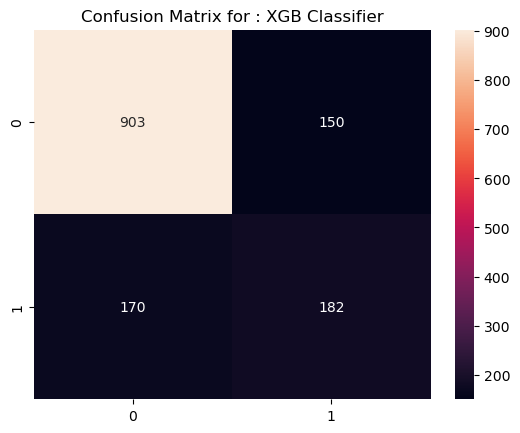

 <===Random Forest===> 
              precision    recall  f1-score   support

           0    0.90842   0.70655   0.79487      1053
           1    0.47270   0.78693   0.59062       352

    accuracy                        0.72669      1405
   macro avg    0.69056   0.74674   0.69275      1405
weighted avg    0.79926   0.72669   0.74370      1405



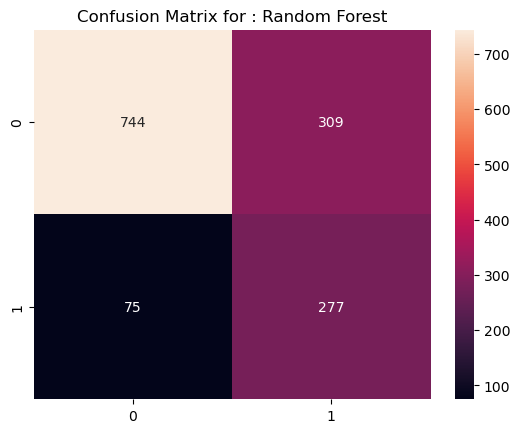

 <===K-nearest Neighbours===> 
              precision    recall  f1-score   support

           0    0.84222   0.76543   0.80199      1053
           1    0.44866   0.57102   0.50250       352

    accuracy                        0.71673      1405
   macro avg    0.64544   0.66823   0.65225      1405
weighted avg    0.74362   0.71673   0.72696      1405



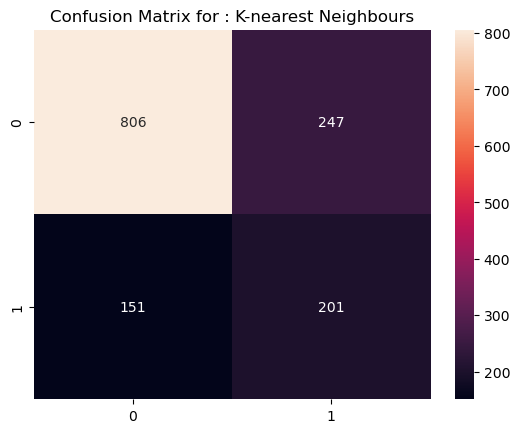

 <===SGD Classifier===> 
              precision    recall  f1-score   support

           0    0.91794   0.62678   0.74492      1053
           1    0.42711   0.83239   0.56455       352

    accuracy                        0.67829      1405
   macro avg    0.67253   0.72958   0.65473      1405
weighted avg    0.79497   0.67829   0.69973      1405



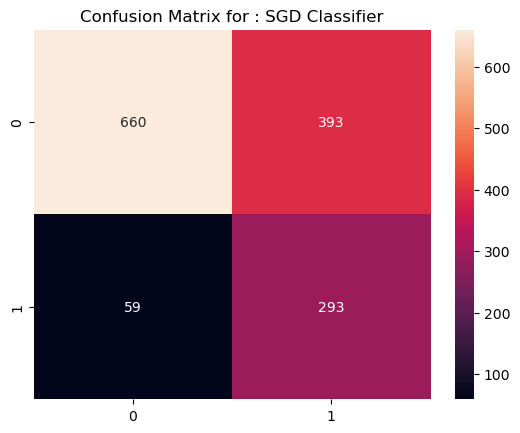

 <===SVC===> 
              precision    recall  f1-score   support

           0    0.91094   0.67996   0.77868      1053
           1    0.45557   0.80114   0.58084       352

    accuracy                        0.71032      1405
   macro avg    0.68326   0.74055   0.67976      1405
weighted avg    0.79686   0.71032   0.72912      1405



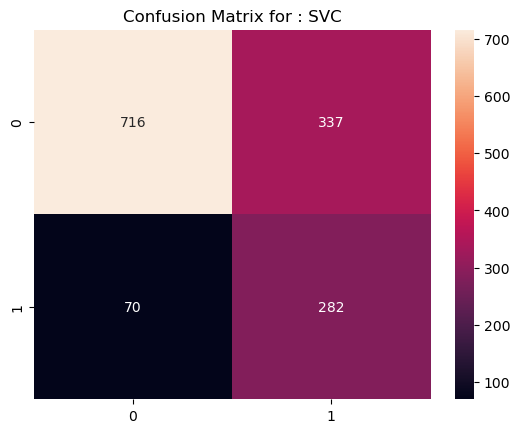

 <===Naive Bayes===> 
              precision    recall  f1-score   support

           0    0.85155   0.80627   0.82829      1053
           1    0.50000   0.57955   0.53684       352

    accuracy                        0.74947      1405
   macro avg    0.67578   0.69291   0.68257      1405
weighted avg    0.76348   0.74947   0.75527      1405



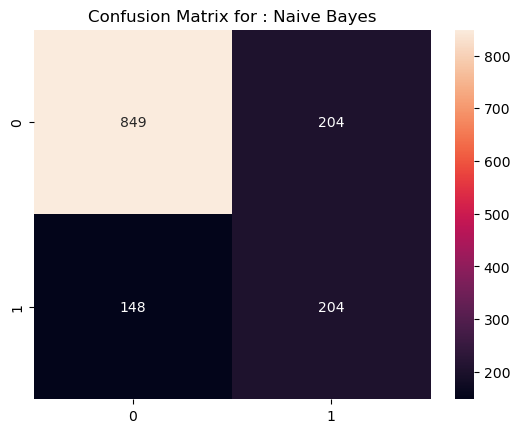

 <===Decision tree===> 
              precision    recall  f1-score   support

           0    0.90842   0.70655   0.79487      1053
           1    0.47270   0.78693   0.59062       352

    accuracy                        0.72669      1405
   macro avg    0.69056   0.74674   0.69275      1405
weighted avg    0.79926   0.72669   0.74370      1405



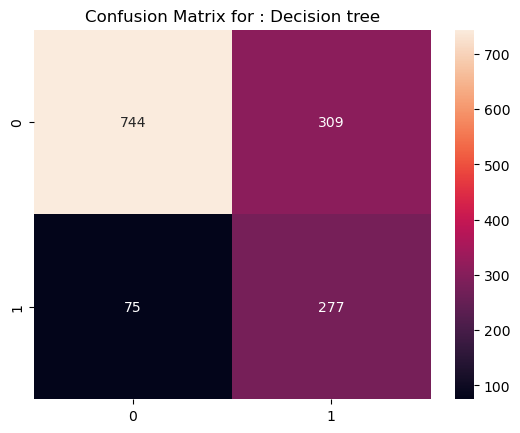

 <===Logistic regression===> 
              precision    recall  f1-score   support

           0    0.93558   0.60684   0.73618      1053
           1    0.42659   0.87500   0.57356       352

    accuracy                        0.67402      1405
   macro avg    0.68109   0.74092   0.65487      1405
weighted avg    0.80806   0.67402   0.69543      1405



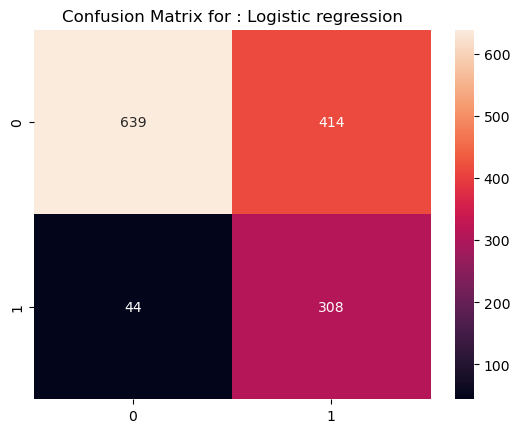

In [149]:
# Model Training the Top 5 important features in XGB Classifiers, through all the 8 classifiers

for classifier in classifiers:
    model = classifier [0]
    model_name = classifier[1]
    print(f" <==={model_name}===> ")
    # Training 
    model = model.fit(Xtrain_top5_scaled_xgb, ytrain)
    # predictions
    predictions = model.predict(Xtest_top5_scaled_xgb)
    report = classification_report (ytest, predictions, digits = 5, zero_division = 0)
    matrix = confusion_matrix(ytest, predictions)
    print(report)
    # Plot
    sns.heatmap(matrix, annot =True, fmt='g')
    plt.title(f'Confusion Matrix for : {model_name}')
    plt.show();